#**Neural approach to Model Order Reduction for the Transport Equation with discontinuous initial conditions: overcoming classical POD limitations in the Missing Data regime**


*In questo notebook esploriamo i limiti intrinseci dell'approccio POD (Proper Orthogonal Decomposition) per la Model Order Reduction (MOR) applicata all'Equazione del Trasporto, con particolare attenzione agli scenari che presentano condizioni iniziali discontinue (es. profili a gradino).In questi casi i metodi classici perdono di efficacia poiché approssimano la soluzione ricercandola in un sottospazio lineare di dimensione $k$. Tuttavia, la varietà (manifold) delle soluzioni di questa PDE risulta fortemente non lineare. Per superare questo ostacolo, ricorriamo alle moderne architetture di Deep Learning, in particolare gli AutoEncoder, ormai noti per la loro vastissima adattabilità nella soluzione di molteplici applicazioni. Queste reti ci permettono di generalizzare la proiezione lineare, comprimendo e ricostruendo la dinamica su una varietà non lineare (curved manifold) della medesima dimensione latente $k$.L'utilizzo di un framework neurale ci ha inoltre permesso di svincolarci dalla dipendenza di un solver esplicito per l'evoluzione temporale, abbattendo l'accumulo di rumore numerico e le instabilità tipicamente indotte dalla classica proiezione nei solver (per i quali è necessario operare all'interno delle rispettive regioni di stabilità). Infine, estendiamo questo approccio al regime dei dati mancanti (Missing Data). Come evidenziato in letteratura per la fluidodinamica sperimentale (ad es., ricostruzioni tramite rilevatori asincroni [1]), spesso si è costretti a operare con matrici degli snapshot fortemente sparse. Questa condizione pone limiti severi anche nei recenti problemi avanzati come SINDy (Sparse Identification of Nonlinear Dynamics) [2], diventati di vastissimo interesse nella ricerca moderna.*


**References**:

[1] Full-domain POD modes from PIV asynchronous patches (2025).(https://arxiv.org/pdf/2501.05988)


[2] Messenger, D. A., & Bortz, D. M. (2020). Weak SINDy for Partial Differential Equations.(https://arxiv.org/pdf/2007.02848)

# INTRODUZIONE

## **1. Definizione del Problema**
Si consideri un problema del tipo:$$a(u_h, v_h) = F(v_h)$$ossia una forma bilineare che rappresenta un'equazione alle derivate parziali (PDE) discretizzata (ad esempio tramite Metodo agli Elementi Finiti, FEM), dove cerchiamo la soluzione $u_h \in V_h$ tale che soddisfi l'equazione per ogni funzione test $v_h \in V_h$, con $F(V_h) \in V_h^*$, ossia il duale, a cui si aggiungono delle condizioni al contorno (BC) che caratterizzano lo specifico problema fisico. Tuttavia, tipicamente nelle applicazioni pratiche e industriali, questi problemi non sono statici, ma parametrici. Esiste cioè un vettore di parametri fisici, operativi o geometrici $\mu \in \mathbb{P} \subset \mathbb{R}^P$ che va a modificare la natura del problema. Si ottengono così forme dipendenti dal parametro, come:
1. Dominio variabile: $\Omega_h(\mu)$ (es. la geometria del sistema, come la forma aerodinamica di un profilo che cambia)
2. Operatore fisico: $a(u_h, v_h; \mu)$ (es. proprietà del materiale come la conducibilità termica o la viscosità che variano).
3. Termine sorgente/forzante: $F(v_h; \mu)$ (es. un carico meccanico o una sorgente di calore esterna regolabile).
4. Condizioni al contorno: $BC(\mu)$ (es. temperature o pressioni specifiche applicate ai bordi).

## **2. Limite Computazionale**
In molti scenari di vasto interesse risulta fondamentale trovare le soluzioni per le molteplici istanze del parametro $\mu_i$. Ricordando i metodi tradizionali FEM ricordiamo che nel worst case il costo computazionale è $\mathcal{O}(N_h^3)$ e simulare tutti questi scenari diventa proibitivo.

## **3. Model Order Reduction**
Un modo per aggirare il problema è quello di cercare uno spazio vettoriale ridotto $V_n$, generato da una base di funzioni $\{\psi_i\}_{i=1}^n$, la cui dimensione $n$ sia inferiore rispetto ai gradi di libertà originali del sistema completo ($n \ll N_h$). Questo spazio $V_n$ inoltre, deve fornire una buona approssimazione della varietà spaziale generata dall'insieme di tutte le soluzioni esatte al variare dei parametri:$$\{u_h(\mu) \mid \mu \in \mathbb{P}\} \subset V_h$$Per formalizzare questo concetto, ricordiamo che nello spazio FEM ad alta fedeltà ($V_h$), generato dalla base $\{\varphi_i\}_{i=1}^{N_h}$, la soluzione è espressa come $u_h(x) = \sum_{j=1}^{N_h} \varphi_j(x) u_j$. Nello spazio ridotto ROM ($V_n$), la soluzione approssimata viene invece costruita sui nuovi modi di base $\{\psi_i\}_{i=1}^n$ ed espressa come:$$u_n(x) = \sum_{j=1}^n \psi_j(x) \hat{u}_j$$dove $\hat{u}_j$ sono i nuovi coefficienti incogniti. Poiché $V_n$ è un sottospazio di $V_h$, possiamo esprimere ogni funzione di base ridotta come combinazione lineare delle funzioni di base originarie del FEM:$$\psi_i(x) = \sum_{j=1}^{N_h} B_{ji} \varphi_j(x)$$Questo legame definisce una matrice dei coefficienti $B \in \mathbb{R}^{N_h \times n}$ (una matrice "alta e stretta"). Per determinare la matrice $B$ cerchiamo l'approssimazione ottimale di rango $n$. Formalmente, questo si traduce nel seguente problema di minimizzazione in norma di Frobenius: $\min_{\text{rango}(X)=n} \| S - X \|_F$. La soluzione a questo problema è garantita dal teorema di Eckart-Young-Mirsky tramite la Decomposizione a Valori Singolari (SVD), da cui estraiamo la base ortonormale ottimale $B \in \mathbb{R}^{N_h \times n}$,
dove le colonne di $B$ corrisponderanno direzioni spaziali indipendenti dove variano maggiormente i dati. Trovata la base, si assume che la soluzione parametrica possa essere approssimata come $u \approx B\hat{u}$, dove $\hat{u} \in \mathbb{R}^n$ è il vettore dei coefficienti incogniti. A questo punto, il problema originale FEM, che richiedeva di risolvere il gigantesco sistema lineare $A(\mu)u = F(\mu)$ (con $A \in \mathbb{R}^{N_h \times N_h}$), può essere drasticamente ridotto. Impoendo quindi il residuo $r = F - A(B\hat{u})$ ortogonale alla nuova base $B$, e quindi $B^Tr=0$. Il problema si riduce così a trovare il piccolo vettore dei coefficienti incogniti $\hat{u} \in \mathbb{R}^{n \times 1}$, del sistema ROM:$$\hat{A}(\mu)\hat{u} = \hat{F}(\mu),$$ con $\hat{A}(\mu) = B^T A(\mu) B \quad \in \mathbb{R}^{n \times n}$ e $\hat{F}(\mu) = B^T F(\mu) \quad \in \mathbb{R}^{n \times 1}$. Risolvere questo nuovo sistema richiede nel worst case $\mathcal{O}(n^3)$, risultando decisamente meno dispendioso del precedente che richiedeva $\mathcal{O}(N_h^3)$ con $N_h >> n$, ripetuto tante volte quante il numero di parametri che vogliamo provare.

## 1. L'equazione del Trasporto
Per testare l'efficacia e i limiti della *Model Order Reduction* basata su SVD, consideriamo come modello (Full Order Model) l'**Equazione del Trasporto 1D**:
$$\frac{\partial u}{\partial t} + c \frac{\partial u}{\partial x} = 0$$
con Condizioni al Contorno Periodiche (PBC): $u(0,t) = u(L,t)$.

Questa PDE modella il trasporto puro di una quantità $u$ lungo il dominio spaziale a una velocità $c$ che per il momento considereremo $c=1$, per mostrare come funziona la soluzione di un metodo FEM e poi andremo a vedere come al variare di $c$, ossia quindi considerando una lista di valori $c = [c_1,...,c_N]$ varia la soluzione che otteniamo. Quando vogliamo vedere ciò però, come introdotto, dovremmo risolvere il problema $N$ volte sulla griglia di dimensione $N_h \times N_h$, e quindi sarà necessario ridurre il problema su una griglia più piccola.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse.linalg import spsolve
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import time
from scipy.linalg import svd
from scipy.fft import fft, fftfreq
from scipy.interpolate import griddata
import torch, torch.nn as nn, torch.optim as optim
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
from ipywidgets import interact

In [ ]:
class TransportPDE:
    def __init__(self, u0_lambda, x_start=0.0, x_end=2*np.pi, Nx=256, c=1.0, nu=0.0):
      #BOUNDARY CONDITION
        self.x_start = x_start
        self.x_end = x_end
        self.L = x_end - x_start  # La lunghezza viene calcolata dinamicamente

      #GRIGLIA PERIODICA
        self.Nx = Nx
        self.dx = self.L / Nx
        self.x = np.linspace(x_start, x_end, Nx, endpoint=False)

      #PARAMETRI
        self.c = c    # Velocità di advezione
        self.nu = nu  # Coefficiente di diffusione

      #DATO INIZIALE
        self.u0 = u0_lambda(self.x)

# METODI RISOLUTORI
Fondamentale è in generale la scelta del metodo FEM che scegliamo per risolvere il sistema, poichè ogni metodo è caratterizzato da una sua complessità computazionale e un suo ordine di convergenza. In generale cerchiamo un metodo preciso ossia cerchiamo tra i metodi noti quelli che abbiamo p più alto possibile, dove p è il termine che determina l'ordine di convergenza di: $\mathcal{O}(\Delta t^p, \Delta x^p)$. Inoltre vogliamo che il nostro metodo non esploda anche facendo i passi più grandi possibili, il che ci porta a cercare qualcosa del tipo $\Delta t = C \Delta x$.

### 2. Metodo di Eulero Implicito
In particolare se consideriamo il metodo di Eulero Implicito che discetizza la griglia come:
$$\frac{u_i^{n+1} - u_i^n}{\Delta t} + \frac{u_{i+1}^{n+1} - u_{i-1}^{n+1}}{2\Delta x} = 0$$
A differenza dei metodi espliciti, qui le incognite spaziali sono accoppiate. Per trovare la soluzione al passo successivo, dobbiamo risolvere un **sistema lineare** $A u^{n+1} = u^n$ ad ogni iterazione temporale, dove $A$ è una matrice tridiagonale (che diventa ciclica per via delle condizioni al contorno periodiche), risultando a livello computazionale estremamente oneroso.

In [ ]:
class ImplicitEulerSolver:

    def __init__(self, pde, T_end, dt, dt_save=0.1):
      # Importo la PDE e setto numero di step
        self.pde = pde
        self.T_end = T_end
        self.dt = dt
        self.dt_save = dt_save

        self.Nt = int(np.ceil(self.T_end / self.dt))
        self.Nt_save = int(np.ceil(self.T_end / self.dt_save)) + 1 #salvo per eccesso

     # matrice del problema
        self.assemble_matrices()

    def assemble_matrices(self):
        Nx = self.pde.Nx
        dx = self.pde.dx

        # 1.Matrice derivata prima
        # Costruita direttamente come matrice sparsa
        D1 = sp.diags([-0.5, 0.5], [-1, 1], shape=(Nx, Nx), format='lil')
        D1[0, -1] = -0.5  # Condizioni periodiche
        D1[-1, 0] =  0.5
        D1 = D1.tocsc() / dx

        # Matrice derivata seconda, caso diffusione
        D2 = sp.diags([1.0, -2.0, 1.0], [-1, 0, 1], shape=(Nx, Nx), format='lil')
        D2[0, -1] = 1.0   # Condizioni periodiche
        D2[-1, 0] = 1.0
        D2 = D2.tocsc() / (dx**2)

        # Matrice LHS
        I = sp.eye(Nx, format='csc')
        self.lhs_matrix = I + (self.dt * self.pde.c * D1) - (self.dt * self.pde.nu * D2)

        # Salvando le matrici sparse risparmiamo tempo computazionale portandolo
        # da  in questo caso con LU sparsa da O(n^3) a O(n)
        self.solve_lhs = spla.factorized(self.lhs_matrix)

    def evolve(self):
      #metodo per stimare la soluzione della pde
        self.U_sol = []
        self.times = []

        un = np.copy(self.pde.u0)
        self.U_sol.append(np.copy(un))
        self.times.append(0.0)

        time = 0.0
        time_save = 0.0

      #stima della soluzione per ogni step temporale
        for it in range(1, self.Nt + 1):
            time += self.dt
            time_save += self.dt

            un = self.solve_lhs(un)

            if time_save >= self.dt_save - 1e-9:
                self.U_sol.append(np.copy(un))
                self.times.append(time)
                time_save = 0.0

        self.U_sol = np.array(self.U_sol)
        return self.pde.x, un

Consideriamo ora in particolare l'intervallo spaziale: $[0,2\pi]$ e l'intervallo temporale $[0,2]$.

In [ ]:
# ==========
# SET UP
# ==========

L = 2 * np.pi
c = 1.0
nu = 0.0 # Trasporto puro
Nx = 200
dt = 0.05
T_end = 2.0
dt_save = 0.4

# Definiamo le IC
initial_center = np.pi
initial_sigma = 0.5
guassian_u0_lambda = lambda x: np.exp(-((x - initial_center)**2) / (2 * initial_sigma**2))
pde = TransportPDE(x_end=L, Nx=Nx, c=c, nu=nu, u0_lambda=guassian_u0_lambda)

# Soluzione esatta
def exact_solution(x, t, c, L):
    x_shifted = (x - c * t) % L
    center = initial_center
    sigma = initial_sigma
    return np.exp(-((x_shifted - center)**2) / (2 * sigma**2))


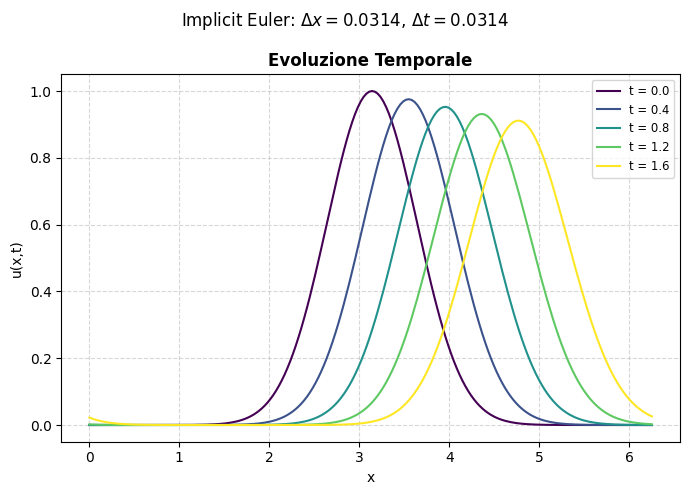

In [ ]:
# plot
Nx = 200
dt = (2*np.pi)/Nx
T_end = 2.0
dt_save = 0.4
solver = ImplicitEulerSolver(pde=pde, T_end=T_end, dt=dt, dt_save=dt_save)
xx, u_final = solver.evolve()
fig1, ax1 = plt.subplots(figsize=(7, 5))

colors = plt.cm.viridis(np.linspace(0, 1, len(solver.times)))
for it, time in enumerate(solver.times):
    ax1.plot(xx, solver.U_sol[it], color=colors[it], label=f"t = {time:.1f}")

ax1.set_title("Evoluzione Temporale", fontsize=12, fontweight='bold')
ax1.set_xlabel("x")
ax1.set_ylabel("u(x,t)")
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right', fontsize='small')

fig1.suptitle(rf"Implicit Euler: $\Delta x={pde.dx:.4f}, \, \Delta t={solver.dt:.4f}$")
plt.tight_layout()
plt.show()

Vediamo dal plot come dal solver vengano smussati i picchi dell'onda all'avanzare del tempo. Infatti per un'equazione di trasporto pura ($u_t + c u_x = 0$) con condizioni al contorno periodiche e una velocità $c$ costante, la soluzione esatta $u_{exact}(x, t)$ è una semplice traslazione della condizione iniziale. In questo studio abbiamo ipotizzato un profilo iniziale gaussiano, ossia una funzione generica della forma $f(x) = e^{-\frac{(x - \mu)^2}{2\sigma^2}}$, che ci ha portato quindi a definire la condizione iniziale specifica come $u_0(x) = e^{-\frac{(x - \pi)^2}{2(0.5)^2}}$. La soluzione esatta è semplicemente questa $u_0(x)$ traslata nello spazio di una quantità pari a $c \cdot t$. Ovvero, vale la relazione $u_{exact}(x, t) = u_0(x - c t)$. Ricordando che nel nostro caso trattiamo $c = 1$, la formula analitica finale risulta essere:$$u_{exact}(x, t) = e^{-\frac{(x - t - \pi)^2}{2(0.5)^2}}$$

Confrontiamo ora i profili ottenuti dal metodo di Eulero Implicito con la soluzione esatta in alcuni istanti di tempo.

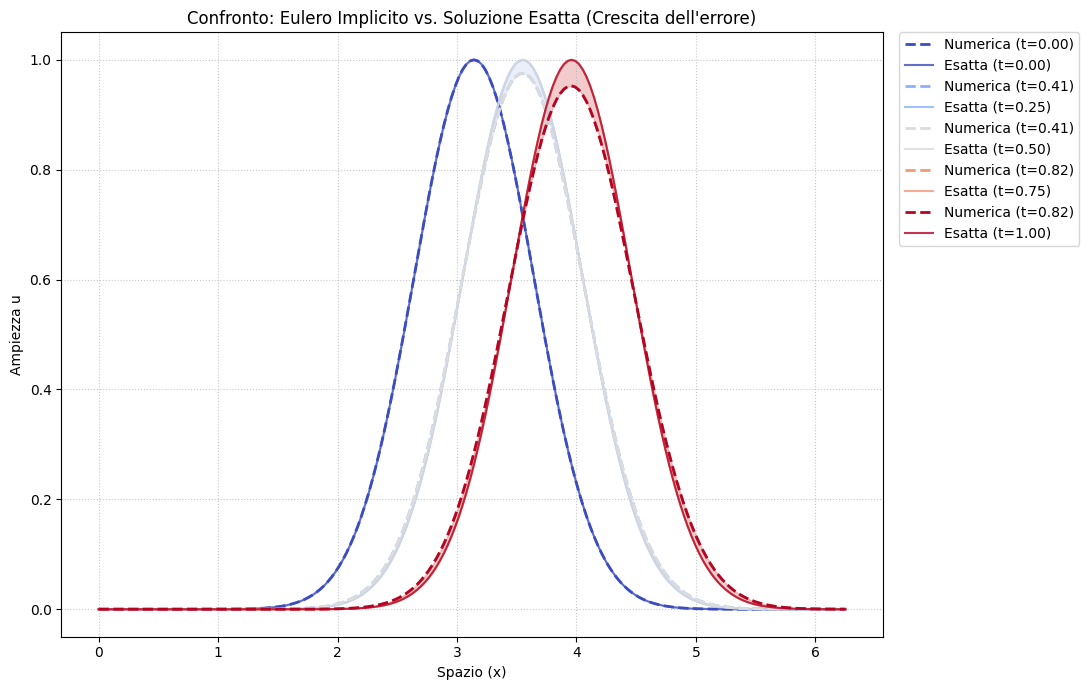

In [ ]:
plt.figure(figsize=(11, 7))

# Tempi da plottare
plot_times_comp = np.linspace(0, 1, 5)
current_times_sim = np.array(solver.times)

# Usiamo una colormap per avere un colore distinto per ogni step temporale
colors = plt.cm.coolwarm(np.linspace(0, 1, len(plot_times_comp)))

for idx, t_val in enumerate(plot_times_comp):
    # Indice più vicino nella simulazione
    closest_idx = np.argmin(np.abs(current_times_sim - t_val))
    t_actual = current_times_sim[closest_idx]

    # Seleziono il colore per questo specifico istante temporale
    c = colors[idx]

    # Soluzione numerica (Eulero Implicito)
    u_num = solver.U_sol[closest_idx, :]
    plt.plot(pde.x, u_num, '--', color=c, linewidth=2, label=f'Numerica (t={t_actual:.2f})')

    # Soluzione esatta
    exact_solution_val = exact_solution(pde.x, t_actual, pde.c, pde.L)

    plt.plot(pde.x, exact_solution_val, '-', color=c, alpha=0.8, label=f'Esatta (t={t_val:.2f})')

    # area per visualizzare l'errore
    plt.fill_between(pde.x, exact_solution_val, u_num, color=c, alpha=0.15)

plt.title("Confronto: Eulero Implicito vs. Soluzione Esatta (Crescita dell'errore)")
plt.xlabel("Spazio (x)")
plt.ylabel("Ampiezza u")

# Spostiamo la legenda fuori dal plot per non coprire le onde
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

Sebbene questo schema richieda la risoluzione di un sistema lineare a ogni iterazione, offre notevoli vantaggi in termini di stabilità. Lo schema alle differenze si scrive come:

$$\frac{u_i^{n+1} - u_i^n}{\Delta t} + \frac{u_{i+1}^{n+1} - u_{i-1}^{n+1}}{2\Delta x} = 0$$

L'ordine di convergenza di questo metodo è $\mathcal{O}(\Delta t, \Delta x^2)$, ovvero è del primo ordine nel tempo e del secondo ordine nello spazio.

**Analisi di Von Neumann**:
Per studiare la stabilità, l'analisi di Von Neumann inserisce nello schema numerico una singola componente armonica (dove supponiamo di scrivere la soluzione come combinazione nella base di Fourier: $u_j^n = g^n e^{ikj\Delta x}$) per verificare se il fattore di amplificazione $g(k)$ decresce o esplode nel tempo. Sostituendo, otteniamo:

$$1 + \frac{\Delta t}{2\Delta x}\left(e^{ik\Delta x} - e^{-ik\Delta x}\right) = 1 + \frac{\Delta t}{\Delta x}i\sin(k\Delta x)$$

Risolvendo per il fattore di amplificazione $|g(k)|$:

$$|g(k)| = \left|1 + \frac{\Delta t}{\Delta x}i\sin(k\Delta x)\right|^{-1} < 1, \qquad \forall k \in \mathbb{R}.$$

Il metodo risulta **incondizionatamente stabile**, ma il fatto che il fattore di amplificazione sia sempre strettamente minore di 1 solleva un problema fisico per un'equazione puramente conservativa (che dovrebbe mantenere intatta la propria energia), risultando la causa dei picchi smussati.

Mentre la soluzione esatta conserva la norma $\|u(t)\|_{L^2} = \|u(0)\|_{L^2}$ (vale l'uguale del Trm. Parseval), la soluzione numerica subirà una forte **dissipazione artificiale**, portando dopo molti passi temporali a un'energia irrealistica:
$\|u^n\|_{L^2} = |g(k)|^n\|u(0)\|_{L^2} \ll \|u(0)\|_{L^2}$.

### 1.Metodo di Eulero Esplicito

Un altro possibile metodo per risolvere il sistema potrebbe essere quello di considerare il Metodo di Eulero Esplicito. Tuttavia anche qui se consideriamo questo metodo con differenze finite centrali, ossia della forma:
$$\frac{u_i^{n+1} - u_i^n}{\Delta t} + \frac{u_{i+1}^n - u_{i-1}^n}{2 \Delta x} = 0 $$
con ordine di convergenza $\mathcal{O}(\Delta t^2, \Delta x^2)$, ossia di secondo ordine nel tempo e nello spazio.
Si dimostra tramite il metodo di Von Neumann che:
$$|g(k)|^2 = 1 + \left(\frac{\Delta t}{\Delta x} \sin(k \Delta x)\right)^2,$$
ma tuttavia per la stabilità di Lax-Rictmyer vogliamo che $|g(k)| < 1 + \alpha \Delta t$, il che ci costringe a scegliere $\Delta t = C \Delta x^2$.

Una correzione di ordine superiore è il metodo **Lax-Wendroff**, che stabilizza lo schema aggiungendo un termine di diffusione numerica calibrato per ottenere il secondo ordine di accuratezza:
$$u_i^{n+1} = u_i^n - c \frac{\Delta t}{2\Delta x} (u_{i+1}^n - u_{i-1}^n) + \frac{c^2 \Delta t^2}{2 \Delta x^2} (u_{i+1}^n - 2u_i^n + u_{i-1}^n)$$

L'analisi di Von Neumann restituisce (ponendo il numero di Courant $\nu = c\frac{\Delta t}{\Delta x}$):
$$g(k) = 1 - i \nu \sin(k\Delta x) + \nu^2 (\cos(k\Delta x) - 1)$$

Calcolando il modulo quadro e usando l'identità trigonometrica $1 - \cos(k\Delta x) = 2\sin^2\left(\frac{k\Delta x}{2}\right)$:
$$|g(k)|^2 = 1 - 4\nu^2 (1 - \nu^2) \sin^4\left(\frac{k\Delta x}{2}\right)$$

Affinché sia $|g(k)| \le 1$, il termine sottratto deve essere sempre positivo, il che ci impone $1 - \nu^2 \ge 0$. Dobbiamo quindi imporre la **Condizione CFL (Courant-Friedrichs-Lewy)**:
$$c \frac{\Delta t}{\Delta x} \le 1$$

che ci permette di ottenere $\Delta t \le \frac{1}{c} \Delta x$, che corrisponde all'andamento lineare $\Delta t = C \Delta x$, ossia ciò che stavamo cercando.

In [ ]:
class Explicit_Euler_LW:
    def __init__(self, pde, T_end, dt, dt_save=0.1):

        self.pde = pde #import pde
        self.T_end = T_end
        self.dt = dt
        self.dt_save = dt_save

        self.Nt = int(np.ceil(self.T_end / self.dt))
        self.Nt_save = int(np.ceil(self.T_end / self.dt_save)) + 1

    def evolve(self):
        self.U_sol = []
        self.times = []

        un = np.copy(self.pde.u0)
        self.U_sol.append(np.copy(un))
        self.times.append(0.0)

        time = 0.0
        time_save = 0.0

        c = self.pde.c
        dx = self.pde.dx
        dt = self.dt

        for it in range(1, self.Nt + 1):
            time += dt
            time_save += dt

            # stima di {u_i+1} e {u_i-1}
            u_left = np.roll(un, 1)
            u_right = np.roll(un, -1)

            # METODO DI LAX-WENDROFF
            nu = c * dt / dx  # Numero di Courant
            un = un - 0.5 * nu * (u_right - u_left) + 0.5 * (nu**2) * (u_right - 2.0 * un + u_left)

            # Salvataggio
            if time_save >= self.dt_save - 1e-9:
                self.U_sol.append(np.copy(un))
                self.times.append(time)
                time_save = 0.0

        self.U_sol = np.array(self.U_sol)
        return self.pde.x, un

# uso come IC la soluzione al tempo 0
def exact_solution(x, t, c, L, center=np.pi, sigma=0.5):
    # PBC
    x_shifted = (x - c * t) % L
    return np.exp(-((x_shifted - center)**2) / (2 * sigma**2))

#Inizializzazione Problema
center = np.pi
sigma = 0.5
u0_lambda = lambda x: exact_solution(x, 0, c=1.0, L=2*np.pi, center=center, sigma=sigma)

# Creiamo la PDE
pde = TransportPDE(x_end=2*np.pi, Nx=100, c=1.0, nu=0.0, u0_lambda=u0_lambda)

# Parametri Temporali e Risoluzione
T_end = 1.0
dt = 0.01
dt_save = 0.2

# Utilizziamo il nuovo solutore LW
solver = Explicit_Euler_LW(pde=pde, T_end=T_end, dt=dt, dt_save=dt_save)
xx, u_final = solver.evolve()

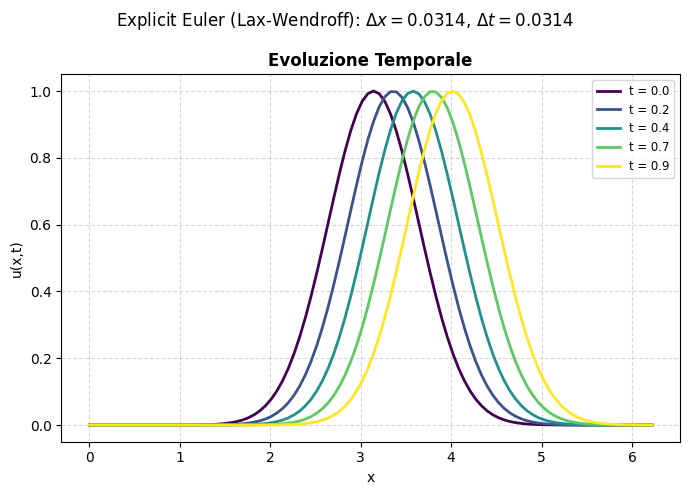

In [ ]:
# Plot
fig1, ax1 = plt.subplots(figsize=(7, 5))
T_end1 = 1.0
Nx1 = 200
L = 2*np.pi
dt1 = L/Nx1
dt_save1 = 0.2

# Utilizziamo il nuovo solutore LW
solver = Explicit_Euler_LW(pde=pde, T_end=T_end1, dt=dt1, dt_save=dt_save1)
xx1, u_final1 = solver.evolve()
# Mappatura dei colori basata sul numero di step temporali salvati
colors = plt.cm.viridis(np.linspace(0, 1, len(solver.times)))

for it, time in enumerate(solver.times):
    ax1.plot(xx1, solver.U_sol[it], color=colors[it], label=f"t = {time:.1f}", linewidth=2)

ax1.set_title("Evoluzione Temporale", fontsize=12, fontweight='bold')
ax1.set_xlabel("x")
ax1.set_ylabel("u(x,t)")
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right', fontsize='small')

# Titolo globale con i parametri di discretizzazione
fig1.suptitle(rf"Explicit Euler (Lax-Wendroff): $\Delta x={L/Nx1:.4f}, \, \Delta t={solver.dt:.4f}$")
plt.tight_layout()
plt.show()

Utilizzando lo schema di Lax-Wendroff osserviamo come in questo caso avendo $Δt = CΔx$ il solver riesce ad approssimare perfettamente la soluzione. Infatti se osserviamo ora il plot del confronto:

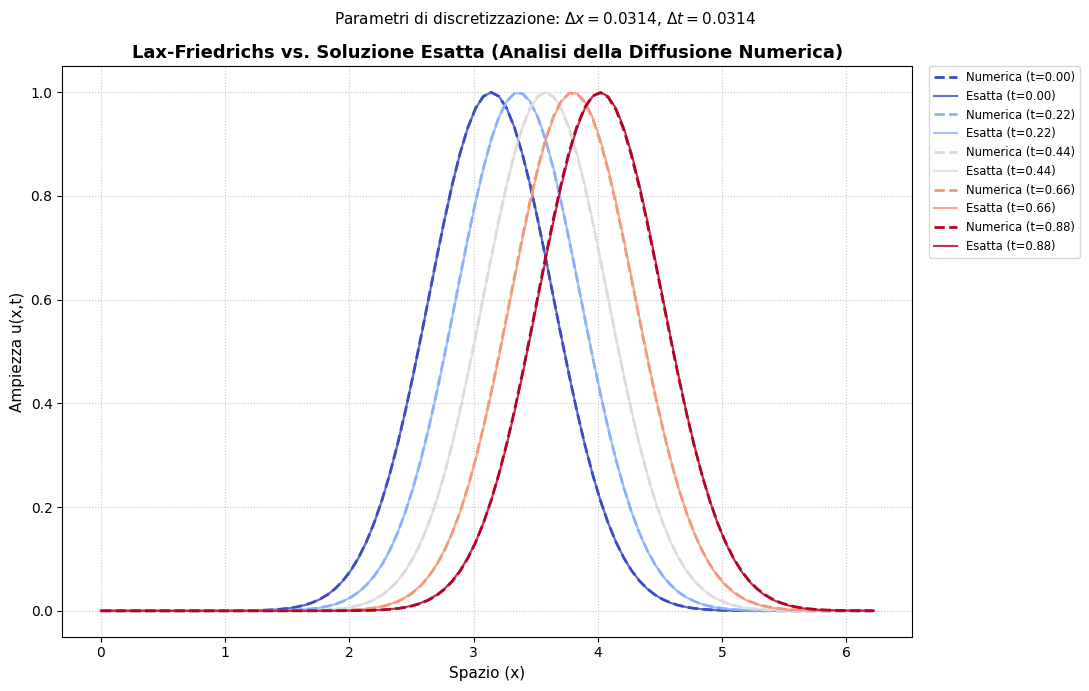

In [ ]:
fig, ax = plt.subplots(figsize=(11, 7))

# Tempi da plottare (es. 5 istanti equidistanti tra 0 e T_end)
plot_times_comp = np.linspace(0, T_end, 5)
current_times_sim = np.array(solver.times)

# Colormap per distinguere gli step temporali
colors = plt.cm.coolwarm(np.linspace(0, 1, len(plot_times_comp)))

for idx, t_val in enumerate(plot_times_comp):
    closest_idx = np.argmin(np.abs(current_times_sim - t_val))
    t_actual = current_times_sim[closest_idx]
    c_color = colors[idx]

    # Plot Soluzione Numerica (tratteggiata)
    u_num = solver.U_sol[closest_idx, :]
    ax.plot(pde.x, u_num, '--', color=c_color, linewidth=2,
            label=f'Numerica (t={t_actual:.2f})')

    # Plot Soluzione Esatta (continua)
    exact_solution_val = exact_solution(pde.x, t_actual, pde.c, pde.L, center, sigma)
    ax.plot(pde.x, exact_solution_val, '-', color=c_color, alpha=0.8,
            label=f'Esatta (t={t_actual:.2f})')

    # Area colorata tra le due curve per visualizzare la dissipazione numerica
    ax.fill_between(pde.x, exact_solution_val, u_num, color=c_color, alpha=0.15)


#plot
ax.set_title("Lax-Friedrichs vs. Soluzione Esatta (Analisi della Diffusione Numerica)", fontsize=13, fontweight='bold')
ax.set_xlabel("Spazio (x)", fontsize=11)
ax.set_ylabel("Ampiezza u(x,t)", fontsize=11)
ax.grid(True, linestyle=':', alpha=0.7)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., fontsize='small')
fig.suptitle(rf"Parametri di discretizzazione: $\Delta x={L/Nx1:.4f}, \, \Delta t={solver.dt:.4f}$", fontsize=11)
plt.tight_layout()
plt.show()

# MODEL ORDER REDUCTION VIA POD

Un modo per comprendere meglio come funziona il metodo di riduzione dell'ordine dei modelli (MOR) tramite proiezione è osservare la sua applicazione su una PDE come quella del trasporto. Consideriamo l'operatore spaziale discreto (matrice) dipendente dal parametro della velocità dell'onda $\mu = c$. Possiamo notare che:$$A(\mu) = cD_1$$dove $D_1$ è la matrice di discretizzazione della derivata prima spaziale. Questa espressione ci indica che la matrice $A(\mu)$ gode della proprietà di decomposizione affine: può essere espressa come combinazione lineare di funzioni scalari dipendenti dal parametro (coefficienti $\Theta$) e matrici indipendenti dal parametro. Nel caso generale, questo si scrive come:$$A(\mu) = \sum_{q=1}^{Q_a} \Theta_q^a(\mu) A_q.$$ Poiché le matrici $A_q$ dipendono esclusivamente dalla topologia della griglia e dallo schema numerico, rimangono costanti al variare del parametro fisico $\mu$. Questo permette di sfruttare una separazione computazionale in due stadi:

1)**Fase Offline**: Prima di iniziare la simulazione parametrica reale, si estrae una base ridotta di dimensione $n \ll N_h$ . Detta $B \in \mathbb{R}^{N_h \times n}$ la matrice contenente le basi dello spazio ridotto si proiettano le componenti indipendenti dal parametro. Questa operazione gravosa viene eseguita una sola volta:$$\hat{A}_q = B^T A_q B$$Il costo computazionale di questa proiezione scala come $\mathcal{O}(N_h \times n^2)$.

2)**Fase Online**: Durante la simulazione reale, per esplorare un nuovo set di parametri $\mu$ (es. una nuova velocità $c$), il modello non deve in alcun modo ricalcolare i grandi operatori originali. Sarà sufficiente assemblare il sistema ridotto come pura combinazione lineare algebrica:$$\hat{A}(\mu) = \sum_{q=1}^{Q_a} \Theta_q^a(\mu) \hat{A}_q$$Essendo $\hat{A}(\mu)$ una matrice densa ma di dimensioni piccolissime ($n \times n$), la risoluzione del sistema algebrico ridotto per trovare i coefficienti incogniti $\hat{u}$ richiede un costo computazionale irrisorio pari a $\mathcal{O}(n^3)$. A questo punto poi riproiettiamo la soluzione nello spazio originale: $$u(\mu) \approx B \hat{u}(\mu)$$ come descritto in precedenza.

In [ ]:
class POD_Basis:
    def __init__(self, n_modes):
        self.n_modes = n_modes
        self.B = None
        self.S_vals = None

    def fit(self, S, mask=None):
        # con maschera (utile per dopo)
        if mask is not None:
            S_processata = S * mask
        else:
            S_processata = S

        #calcolo della SVD della matrice degli snapshot
        U, self.S_vals, _ = np.linalg.svd(S_processata, full_matrices=False)

        # matrice della proiezione di cui prendiamo solo i primi k-modi
        self.B = U[:, :self.n_modes]
        return self.B

Per quanto detto sul metodo di **Lax-Wendroff** quindi,possiamo dunque per la **POD** scomporre la matrice dipendente solo dalla griglia come:
$$A(c) = I - c(\Delta t D_1) + c^2\left(\frac{1}{2}\Delta t^2 D_2\right) = \sum_{q=1}^{3} \Theta_q(c) A_q$$


In [ ]:
class LaxWendroff_ROM:

    def __init__(self, B, D1, D2, dt):
        self.B = B
        self.dt = dt
        self.n_modes = B.shape[1]

        # FASE OFFLINE:
        self.A1_hat = np.eye(self.n_modes)
        self.A2_hat = self.B.T @ (-self.dt * D1) @ self.B
        self.A3_hat = self.B.T @ (0.5 * (self.dt**2) * D2) @ self.B

    def evolve(self, c_val, u0, T_end, dt_save=0.1):

      # FASE ONLINE:
        Nt = int(np.ceil(T_end / self.dt))

        # 1. Assemblaggio operatore ridotto (Costo piccolissimo: O(n_modes^2))
        A_rom = self.A1_hat + c_val * self.A2_hat + (c_val**2) * self.A3_hat

        # 2. Proiezione della condizione iniziale
        a = self.B.T @ u0

        U_sol_r = [np.copy(a)]
        times = [0.0]

        time = 0.0
        time_save = 0.0

        # 3. Iterazione temporale rapida
        for it in range(1, Nt + 1):
            time += self.dt
            time_save += self.dt

            a = A_rom @ a

            if time_save >= dt_save - 1e-9:
                U_sol_r.append(np.copy(a))
                times.append(time)
                time_save = 0.0

        # 4. Ricostruzione finale nello spazio originale ad alta dimensionalità
        u_final = self.B @ a
        return u_final, U_sol_r, times

In [ ]:
# --- 1. Costruzione delle Matrici Operatore FOM (BC Periodiche)
Nx = pde.Nx
dx = pde.dx

# Matrice Derivata Prima Centrale D1
D1 = np.zeros((Nx, Nx))
for i in range(Nx):
    D1[i, (i + 1) % Nx] = 0.5 / dx
    D1[i, (i - 1) % Nx] = -0.5 / dx

# Matrice Derivata Seconda Centrale D2
D2 = np.zeros((Nx, Nx))
for i in range(Nx):
    D2[i, (i + 1) % Nx] = 1.0 / (dx**2)
    D2[i, i] = -2.0 / (dx**2)
    D2[i, (i - 1) % Nx] = 1.0 / (dx**2)

# parametri c
c_train = [0.8, 1.0, 1.2]
snapshots_smooth = []

# Assuming u0_lambda (gaussian) is defined from previous cells (e.g., in 8u16wM9s__hM)
for c_val in c_train:
    pde_train_smooth = TransportPDE(x_end=2*np.pi, Nx=100, c=c_val, nu=0.0, u0_lambda=u0_lambda)
    # Salviamo ad ogni dt per avere snapshot ricchi
    solver_train_smooth = Explicit_Euler_LW(pde=pde_train_smooth, T_end=T_end, dt=dt, dt_save=dt)
    _, _ = solver_train_smooth.evolve()
    for sol in solver_train_smooth.U_sol:
        snapshots_smooth.append(sol)

# Matrice degli Snapshots (Nx x Numero_Totale_Snapshot)
S_smooth = np.array(snapshots_smooth).T

# Calcolo POD tramite SVD
U_smooth, S_vals, Vt_smooth = np.linalg.svd(S_smooth, full_matrices=False)

# Scegliamo il numero di modi POD (dimensione dello spazio ridotto)
n_modes_liscia = 8
B = U_smooth[:, :n_modes_liscia] # Matrice di Base Ridotta (Nx x n_modes)


Vediamo effettivamente a livello comuptazionale quanto sia meno oneroso calcolare la soluzione **POD** sulla griglia $n \times n$ rispetto a quella originale **FOM** sulla griglia $N_h \times N_h$.

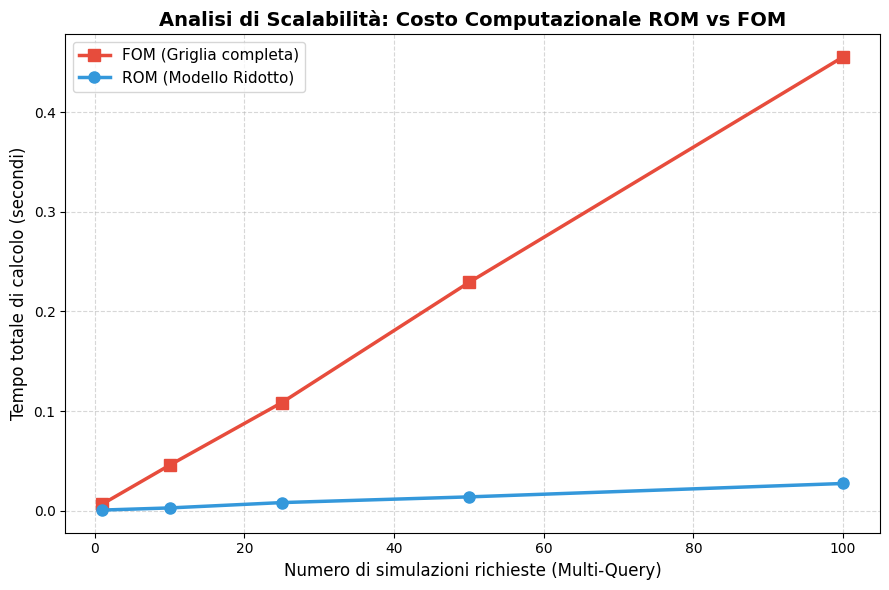

In [ ]:
import time
#numero di soluzioni su cui provo il solver
num_evaluations_list = [1, 10, 25, 50, 100]

fom_cumulative_times = []
rom_cumulative_times = []

#soluzione liscia
rom_solver_liscia = LaxWendroff_ROM(B, D1, D2, dt)

for n_evals in num_evaluations_list:

  #genero valori tra 0.7 e 1.3 (plausibili per c trasporto) tanti quanti il numero su cui lo voglio provare
    c_array = np.linspace(0.7, 1.3, n_evals)

    # --- TIMING FOM ---
    start_fom = time.time()
    for c_val in c_array:
        pde_fom = TransportPDE(x_end=2*np.pi, Nx=200, c=c_val, nu=0.0, u0_lambda=u0_lambda)
        solver_fom = Explicit_Euler_LW(pde=pde_fom, T_end=T_end, dt=dt, dt_save=dt_save)
        solver_fom.evolve()
    fom_cumulative_times.append(time.time() - start_fom)

    # --- TIMING ROM ---
    start_rom = time.time()
    for c_val in c_array:
        u_final_rom, _, _ = rom_solver_liscia.evolve(c_val, u0=pde.u0, T_end=T_end, dt_save=dt_save)
    rom_cumulative_times.append(time.time() - start_rom)


# ==========
# --- PLOT
# ==========
fig, ax = plt.subplots(figsize=(9, 6))

# Plot della scalabilità del FOM (crescita lineare molto ripida)
ax.plot(num_evaluations_list, fom_cumulative_times, marker='s', markersize=8,
         linestyle='-', color='#e74c3c', linewidth=2.5, label='FOM (Griglia completa)')

# Plot della scalabilità del ROM (crescita lineare ma con pendenza quasi nulla)
ax.plot(num_evaluations_list, rom_cumulative_times, marker='o', markersize=8,
         linestyle='-', color='#3498db', linewidth=2.5, label='ROM (Modello Ridotto)')

# Personalizzazione estetica
ax.set_xlabel("Numero di simulazioni richieste (Multi-Query)", fontsize=12)
ax.set_ylabel("Tempo totale di calcolo (secondi)", fontsize=12)
ax.set_title("Analisi di Scalabilità: Costo Computazionale ROM vs FOM", fontsize=14, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

Tuttavia al variare del dato iniziale varia il numero di modi k rilevanti per la nostra POD. Confrontiamo quindi ora con una condizione iniziale spigolosa, ossia: $$u_0(x) = \begin{cases} 1 & \text{se } \frac{\pi}{2} \le x \le \frac{3\pi}{2} \\ 0 & \text{altrimenti} \end{cases}$$

In [ ]:
# --- 1. Definiamo la u_0 Spigolosa (Onda Quadra) ---
def u0_spigolosa(x):
    # Un gradino netto tra pi/2 e 3pi/2
    return np.where((x >= np.pi/2) & (x <= 3*np.pi/2), 1.0, 0.0)

snapshots_quadra = []

for c_val in c_train:
    # Inizializziamo la PDE con l'onda quadra
    pde_train_quadra = TransportPDE(x_end=2*np.pi, Nx=100, c=c_val, nu=0.0, u0_lambda=u0_spigolosa)

    # Risolviamo e salviamo tutti gli step
    solver_train_quadra = Explicit_Euler_LW(pde=pde_train_quadra, T_end=T_end, dt=dt, dt_save=dt)
    solver_train_quadra.evolve()

    for sol in solver_train_quadra.U_sol:
        snapshots_quadra.append(sol)

# --- 3. Matrice degli Snapshots e SVD ---
S_quadra = np.array(snapshots_quadra).T
U_quadra, S_vals_quadra, Vt_quadra = np.linalg.svd(S_quadra, full_matrices=False)

Inoltre andremo a plottare sia i $\sigma_S^2$ ottenuti dalla matrice diagonale dei valori singolari $\hat{S}$  della SVD decomposition, sia la frazione di energia del sistema che riusciamo ad approssimare usando i primi k nodi, formalmente: $$E_k = \frac{\sum_{i=1}^k \sigma_i^2}{\sum_{i=1}^{N} \sigma_i^2}$$

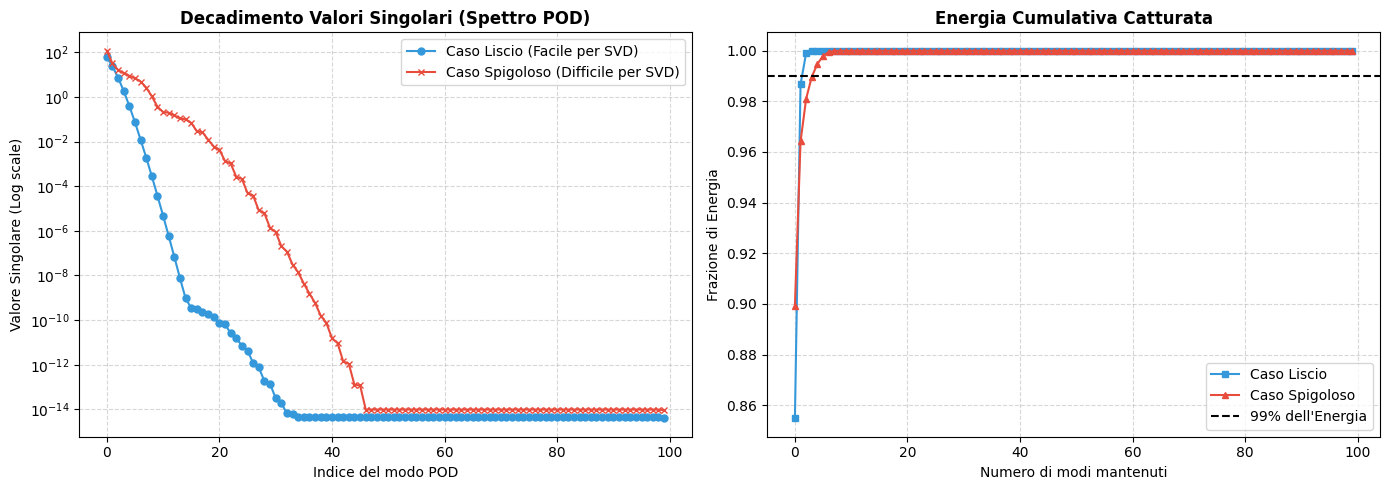

In [ ]:
# CORRETTO: Usiamo S_vals invece di S_smooth
cumulative_energy_liscia = np.cumsum(S_vals**2) / np.sum(S_vals**2)
cumulative_energy_quadra = np.cumsum(S_vals_quadra**2) / np.sum(S_vals_quadra**2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Decadimento dei valori singolari ---
# CORRETTO: Usiamo S_vals
ax1.semilogy(S_vals, marker='o', linestyle='-', color='#3498db', markersize=5, label="Caso Liscio (Facile per SVD)")
ax1.semilogy(S_vals_quadra, marker='x', linestyle='-', color='#e74c3c', markersize=5, label="Caso Spigoloso (Difficile per SVD)")
ax1.set_title("Decadimento Valori Singolari (Spettro POD)", fontweight='bold')
ax1.set_xlabel("Indice del modo POD")
ax1.set_ylabel("Valore Singolare (Log scale)")
ax1.grid(True, which="both", ls="--", alpha=0.5)
ax1.legend()

# --- Plot 2: Energia cumulativa ---
ax2.plot(cumulative_energy_liscia, marker='s', linestyle='-', color='#3498db', markersize=5, label="Caso Liscio")
ax2.plot(cumulative_energy_quadra, marker='^', linestyle='-', color='#e74c3c', markersize=5, label="Caso Spigoloso")
ax2.axhline(y=0.99, color='k', linestyle='--', label="99% dell'Energia")
ax2.set_title("Energia Cumulativa Catturata", fontweight='bold')
ax2.set_xlabel("Numero di modi mantenuti")
ax2.set_ylabel("Frazione di Energia")
ax2.grid(True, ls="--", alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.show()

Come vediamo nel caso di un problema con una condizione iniziale più complessa, come quella introdotta, i valori singolari decadono molto più lentamente e quindi per ottenere una soluzione significativa tramite il metodo **POD**, dovremmo salvare molti più modi k per ottenere soluzioni accurate. Una teoria più rigorosa di questo è fatta a partire da Arbes, Greif e Urban (2025), che ho analizzato in appendice **A[1]**. Inoltre dal secondo grafico sembrerebbe che con $k=[10,15]$ nodi riusciamo effettivamente a stimare tutta l'energia del sistema (99%), consideriamo anche il caso k=15, per vedere la forma che stimerebbe il metodo POD applicando sulla griglia piccola $(n \times n)$ il metodo **Lax-Wendroff**, e ovviamente poi riproiettando la soluzione nello spazio $N_h$ vediamo che soluzione otterremmo in termini di forma.

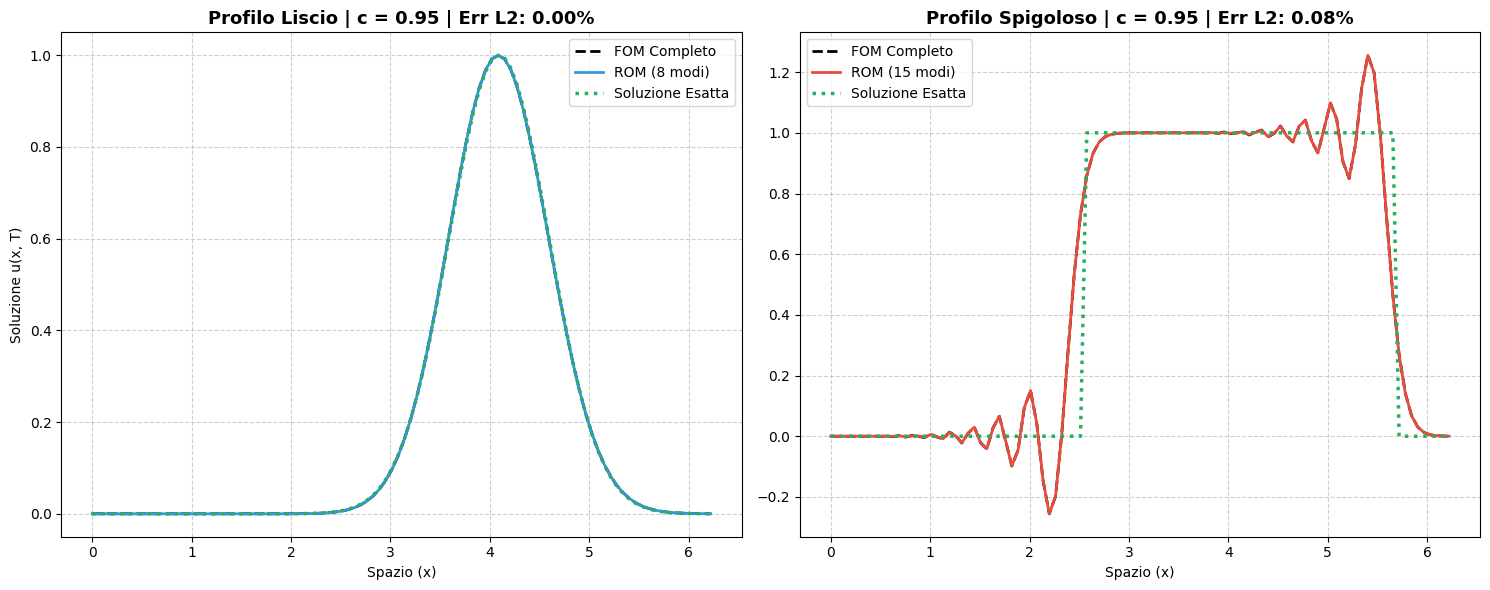

In [ ]:
# 1. Definiamo il parametro non visto durante il training
c_test = 0.95
L = 2 * np.pi
x_grid = np.linspace(0, L, 100, endpoint=False)

# --- Definizione per il caso spigoloso (onda quadra) ---
# Si usa 15 modi per catturare l'energia necessaria, come discusso nella sezione precedente.
n_modes_quadra = 15
B_quadra = U_quadra[:, :n_modes_quadra] # Matrice di Base Ridotta (Nx x n_modes_quadra)
rom_solver_spigoloso = LaxWendroff_ROM(B_quadra, D1, D2, dt)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# =======================
# CASO 1: L'ONDA LISCIA
# =======================
# Ground Truth FOM
pde_test_liscia = TransportPDE(x_end=L, Nx=100, c=c_test, nu=0.0, u0_lambda=u0_lambda)
solver_test_fom_liscia = Explicit_Euler_LW(pde=pde_test_liscia, T_end=T_end, dt=dt, dt_save=dt_save)
solver_test_fom_liscia.evolve()
u_fom_final_liscia = solver_test_fom_liscia.U_sol[-1]

# ROM
u_rom_final_liscia, _, _ = rom_solver_liscia.evolve(c_val=c_test, u0=pde_test_liscia.u0, T_end=T_end)

# Soluzione Esatta Liscia
u_exact_liscia = u0_lambda((x_grid - c_test * T_end) % L)

# Calcolo Errore FOM vs ROM
error_l2_liscia = np.linalg.norm(u_fom_final_liscia - u_rom_final_liscia) / np.linalg.norm(u_fom_final_liscia)

# Plot
ax1.plot(x_grid, u_fom_final_liscia, label="FOM Completo", color='black', linewidth=2, linestyle='--')
# QUI INSERIAMO LA VARIABILE DINAMICA PER I MODI
ax1.plot(x_grid, u_rom_final_liscia, label=f"ROM ({n_modes_liscia} modi)", color='#3498db', linewidth=2)
ax1.plot(x_grid, u_exact_liscia, label="Soluzione Esatta", color='#27ae60', linewidth=2.5, linestyle=':')

ax1.set_title(f"Profilo Liscio | c = {c_test} | Err L2: {error_l2_liscia:.2%}", fontsize=13, fontweight='bold')
ax1.set_xlabel("Spazio (x)")
ax1.set_ylabel("Soluzione u(x, T)")
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()


# =====================
# CASO 2: L'ONDA QUADRA
# =====================
# FOM per onda quadra
pde_test_quadra = TransportPDE(x_end=L, Nx=100, c=c_test, nu=0.0, u0_lambda=u0_spigolosa)
solver_test_fom_quadra = Explicit_Euler_LW(pde=pde_test_quadra, T_end=T_end, dt=dt, dt_save=dt_save)
solver_test_fom_quadra.evolve()
u_fom_final_quadra = solver_test_fom_quadra.U_sol[-1]

# ROM per onda quadra
u_rom_final_quadra, _, _ = rom_solver_spigoloso.evolve(c_val=c_test, u0=pde_test_quadra.u0, T_end=T_end)

# Soluzione Esatta Quadra
u_exact_quadra = u0_spigolosa((x_grid - c_test * T_end) % L)

# Calcolo Errore FOM vs ROM
error_l2_quadra = np.linalg.norm(u_fom_final_quadra - u_rom_final_quadra) / np.linalg.norm(u_fom_final_quadra)

# Plot
ax2.plot(x_grid, u_fom_final_quadra, label="FOM Completo", color='black', linewidth=2, linestyle='--')
# QUI INSERIAMO LA VARIABILE DINAMICA PER I MODI
ax2.plot(x_grid, u_rom_final_quadra, label=f"ROM ({n_modes_quadra} modi)", color='#e74c3c', linewidth=2)
ax2.plot(x_grid, u_exact_quadra, label="Soluzione Esatta", color='#27ae60', linewidth=2.5, linestyle=':')

ax2.set_title(f"Profilo Spigoloso | c = {c_test} | Err L2: {error_l2_quadra:.2%}", fontsize=13, fontweight='bold')
ax2.set_xlabel("Spazio (x)")
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

Come possiamo vedere nel caso spigoloso sono presenti delle oscillazioni in prossimità delle discontinuità. Per una spiegazione intuitiva possiamo considerare infatti la frazione di energia ottenibile tramite i soli primi $k$ valori singolari, definita precedentemente, che può essere riscritta come:

$$
E_k
=
1-\frac{\sum_{i=k+1}^{N}\sigma_i^2}
{\sum_{i=1}^{N}\sigma_i^2},
$$

e poichè i valori singolari $\sigma_i$ sono ottenuti dalla decomposizione ai valori singolari (SVD) della matrice degli snapshot \(D\),

$$
D = U \Sigma V^\top,
$$

di cui consideriamo però come detto solo le prime $k$ componenti:

$$
D_k = U_k \Sigma_k V_k^\top
$$

nel farlo il teorema di Eckart-Young garantisce che questa è la miglior approssimazione ottenibile al rango k che

$$
\|D-D_k\|_F^2
=
\sum_{i=k+1}^{N}\sigma_i^2.
$$

Pertanto,

$$
E_k
=
1-\frac{\|D-D_k\|_F^2}{\|D\|_F^2}.
$$

Poiché la norma di Frobenius della matrice degli snapshot coincide con la somma delle norme $L^2$ al quadrato dei singoli snapshot, il termine

$$
\|D-D_k\|_F^2
$$

rappresenta l'errore $L^2$ quadratico totale introdotto dalla troncatura POD. Ne segue che

$$
E_k
=
1-\frac{\|e\|_{L^2,\mathrm{tot}}^2}{\|D\|_F^2},
$$

dove $\|e\|_{L^2,\mathrm{tot}}^2$ è l'errore totale di ricostruzione. Di conseguenza, massimizzare $E_k$ equivale a minimizzare la norma $L^2$ dell'errore di approssimazione.

Tuttavia a livello visivo ci soffermiamo a vedere l'impatto che ha effettivamente nei punti in cui sbaglia i più, e quindi consideriamo: $$\| u - u_k \|_{L^\infty} = \max_{x} | u(x) - u_k(x) |$$
In questi punti osserviamo un Fenomeno noto come il fenomeno di Gibbs, dove con una serie di k-termini $$u(x,t) \approx \sum_{i=1}^k a_i(t) \phi_i(x),$$
non riusciamo ad aprossimare una funzione che presenta discontinuità di salto e quindi appartiene a una Manifold molto più curva.

# A NEURAL APPROACH

Il metodo **POD** si basa sulla SVD e costruisce una rappresentazione lineare ottimale nello spazio delle soluzioni:
$$
u(x,t) \approx \sum_{j=1}^k a_j(t)\,\phi_j(x),
$$
che equivale alla proiezione su un sottospazio di dimensione $k$. Tuttavia, tale ipotesi fallisce quando la varietà delle soluzioni è non lineare. Nel nostro caso, la condizione iniziale è una funzione discontinua:
$$
u_0(x)=\mathbf{1}_{[\pi/2,\,3\pi/2]}(x),
$$
cioè un’onda quadra, che sotto dinamiche di trasporto conserva la discontinuità ma subisce solo traslazioni. La soluzione appartiene quindi a una famiglia generata da shift, e non a uno spazio lineare a bassa dimensione.

Per superare questo limite si introduce una rappresentazione **encoder–decoder non lineare**:
$$
u \xrightarrow{E} z \xrightarrow{D} \hat u,
\qquad
E:\mathbb{R}^N \to \mathbb{R}^k,\;
D:\mathbb{R}^k \to \mathbb{R}^N.
$$

Nel caso lineare si recupera la POD, mentre nel caso generale si approssima una varietà curva $\mathcal{M}_{phys} \subset \mathbb{R}^N$.

Per quanto introdotto precedentemente, il problema risulta **shift-equivariant**, e inoltre seguendo quanto
introdotto in Bronstein et al. (2021), dobbiamo progettare un architettura che si basa di fatto quindi su questa manifold, ed in particolare ricorreremo quindi all’uso di operatori convolutivi (nel senso classico 1D):
$$
(\mathcal{K} * u)(x)=\sum_j K_j u(x-j).
$$
Un'idea intuitiva del perché la convoluzione funzioni in modo naturale per condizioni al bordo periodiche risiede nella sua diagonalizzazione:

$$
C = F^{-1}\Lambda F
$$

dove $F$ è la base di Fourier discreta, ovvero la base intrinsecamente associata agli operatori lineari invarianti per traslazione.

Mentre l'operatore lineare rispetta le simmetrie spaziali mantenendo le frequenze disaccoppiate, l'aggiunta degli **strati non lineari** permette, ad ogni step, di rimescolare lo spettro trasferendo energia tra le diverse scale. Questo accoppiamento in frequenza estende la manifold che possiamo approssimare a una **varietà altamente non-lineare**.

---

## PINN residual

Per incorporare la struttura della PDE si definisce il residuo:
$$
\mathcal{R}(x,t)=\partial_t \hat u(x,t)+c\,\partial_x \hat u(x,t),
$$
e la relativa penalizzazione:
$$
\mathcal{L}_{phys}=\|\mathcal{R}(x,t)\|_2^2.
$$

Questo termine agisce come vincolo sul manifold appreso, riducendo soluzioni compatibili con i dati ma non con la dinamica fisica.

---

In linea di principio, una volta ricostruito lo stato $\hat u$, sarebbe possibile evolverlo nel tempo mediante uno schema numerico classico, ad esempio Lax-Wendroff. Tuttavia, tali metodi richiedono l'approssimazione esplicita delle derivate spaziali e risultano particolarmente sensibili in presenza di discontinuità.

Per evitare che la stabilità dell'intero modello dipenda dall'applicazione di un solver esterno, si introduce direttamente all'interno della rete un operatore evolutivo appreso:
$$
z_{t+1}=z_t+\mathcal{N}_\theta(z_t),
$$
che svolge il ruolo di solver ridotto nel latent space. In questo modo la dinamica viene appresa direttamente dai dati e dal vincolo fisico, senza passare attraverso l'approssimazione esplicita delle derivate spaziali.

Inoltre per evitare che la rete apprenda esclusivamente una dinamica locale a singolo passo, si introduce un rollout. La lunghezza della traiettoria utilizzata dunque durante il training viene aumentata progressivamente non solo sulla predizione

$$
z_{t+1}=\Phi_\theta(z_t),
$$

ma anche sulle iterazioni successive

$$
z_{t+k}=\Phi_\theta^{\,k}(z_t),
\qquad
k=1,\ldots,T_{roll}.
$$

In questo modo l'errore non viene valutato soltanto localmente, ma sull'intera traiettoria predetta, riducendo l'accumulo di errori che emerge durante le simulazioni autoregressive a lungo termine.
## Loss function finale

La funzione obiettivo combina ricostruzione, consistenza temporale e vincolo fisico:
$$
\mathcal{L}=
\underbrace{\|u-\hat u\|^2}_{\mathcal{L}_{rec}}
+
\underbrace{\sum_{k=1}^{T_{roll}}\|\hat u_{t+k}-u_{t+k}\|^2}_{\mathcal{L}_{roll}}
+
\lambda\underbrace{\|\mathcal{R}(x,t)\|^2}_{\mathcal{L}_{phys}}.
$$

## ARCHITETTURA

In [ ]:
class Conv1DEncoder(nn.Module): #strati convoluzionali di Encoder con PBC
    def __init__(self, Nx, lat, ch=32):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, ch, 15, padding=7, padding_mode='circular'), nn.GELU(),
            nn.Conv1d(ch, ch*2, 9, padding=4, padding_mode='circular'), nn.GELU(),
            nn.Conv1d(ch*2, ch, 5, padding=2, padding_mode='circular'), nn.GELU(),
        )
        self.fc = nn.Linear(Nx * ch, lat)

    def forward(self, x):
        return self.fc(self.conv(x.unsqueeze(1)).flatten(1))


class Conv1DDecoder(nn.Module): #strati deconvoluzionali per apprendere con PBC
    def __init__(self, Nx, lat, ch=32):
        super().__init__()
        self._Nx = Nx
        self._ch = ch
        self.fc = nn.Linear(lat, Nx * ch)
        self.deconv = nn.Sequential(
            nn.ConvTranspose1d(ch, ch*2, 5, padding=2), nn.GELU(),
            nn.ConvTranspose1d(ch*2, ch, 9, padding=4), nn.GELU(),
            nn.ConvTranspose1d(ch, 1, 15, padding=7),
        )

    def forward(self, z):
        return self.deconv(self.fc(z).view(-1, self._ch, self._Nx)).squeeze(1)


class ParametricDynamics(nn.Module): #solver per il latente
    def __init__(self, lat, hid=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(lat + 1, hid), nn.GELU(),
            nn.Linear(hid, hid),     nn.GELU(),
            nn.Linear(hid, hid),     nn.GELU(),
            nn.Linear(hid, lat)
        )
        self.scale = nn.Parameter(torch.ones(1) * 0.1)

    def forward(self, z, mu):
        delta = self.net(torch.cat([z, mu], dim=1))
        return z + self.scale * delta


class ParametricNeuralROM(nn.Module): #architettura finale
    def __init__(self, Nx, lat=20, ch=32):
        super().__init__()
        self.enc = Conv1DEncoder(Nx, lat, ch)
        self.dec = Conv1DDecoder(Nx, lat, ch)
        self.dyn = ParametricDynamics(lat)

    def forward(self, x_seq, mu_val, T_roll=2):
        T = x_seq.shape[0]
        mu_n = self._norm_mu(mu_val, T)
        z    = self.enc(x_seq)
        rec  = self.dec(z)
        preds = []
        zc, mu_roll = z[:-T_roll], mu_n[:-T_roll]
        for _ in range(T_roll):
            zc = self.dyn(zc, mu_roll)
            preds.append(self.dec(zc))
        return rec, preds

    def predict_trajectory(self, u_ic, mu_val, n_steps): #parametrizza la traiettoria simulata
        mu_t = self._norm_mu(float(mu_val), 1)
        z = self.enc(torch.tensor(u_ic, dtype=torch.float32).unsqueeze(0).to(device))
        traj = [self.dec(z).squeeze(0).cpu().detach().numpy()]
        for _ in range(n_steps - 1):
            z = self.dyn(z, mu_t)
            traj.append(self.dec(z).squeeze(0).cpu().detach().numpy())
        return np.array(traj).T

    @staticmethod
    def _norm_mu(mu_val, T):
        mu_n = (float(mu_val) - 1.0) / 0.4
        return torch.tensor([[mu_n]] * T, dtype=torch.float32).to(device)


#PINN APPROACH
def physics_aware_loss(rec, x_seq, preds, targets, mu):
    # MSE LOSS
    l_rec = F.mse_loss(rec, x_seq)
    l_pred = 0.0
    for k, (pred, tgt) in enumerate(zip(preds, targets)):
        w = 1.0 + 0.5 * k
        l_pred += w * F.mse_loss(pred, tgt)

    l_grad = 0.0
    for pred, tgt in zip(preds, targets):
        gp = pred[:, 1:] - pred[:, :-1]
        gt = tgt[:, 1:]  - tgt[:, :-1]
        l_grad += F.mse_loss(gp, gt)

    return l_rec + l_pred + 0.1 * l_grad


# ROLLOUT SU RESIDUO FISICO
def get_T_roll(epoch, max_epoch=1200, t_min=2, t_max=10):
    return min(t_min + int(epoch / max_epoch * (t_max - t_min)), t_max)


## SETUP E TRAIN

Considerando $$u_0(x) = \begin{cases} 1 & \text{se } \frac{\pi}{2} \le x \le \frac{3\pi}{2} \\ 0 & \text{altrimenti} \end{cases}$$

e un dominio $Ω_x \times Ω_t = [0,2\pi] \times [0,1]$ ho simulato le traiettorie e trainato il modello.

Inoltre in questo caso abbiamo splittato i valori di $c$ in $c_{train} = [0.6,0.8,1.0,1.2,1.4] $ e $c_{test} = [0.7, 0.9, 1.1, 1.3]$.

Nel codice della POD precedente su questo problema avevamo considerato in generale $dt = dt \times STRIDE$ con STRIDE = 1, in questo caso consideriamo uno $STRIDE = 10$ per la rete, poichè i vantaggi che otterremo a salvare tutti quegli step in un metodo neurale è poco impattante quindi meglio risparmiare sul costo computazionale, già molto oneroso.

In [ ]:
# ========
# SETUP
# ========

def u0(x):
    return np.where((x >= np.pi/2) & (x <= 3*np.pi/2), 1.0, 0.0)

L = 2*np.pi; Nx = 128; dx = L/Nx
x_grid = np.linspace(0, L, Nx, endpoint=False)
dt = 0.005; T_end = 1.0
SNAP_STRIDE = 10

# Matrici per PINN Loss e Galerkin
D1 = np.zeros((Nx,Nx)); D2 = np.zeros((Nx,Nx))
for i in range(Nx):
    D1[i,(i+1)%Nx]=.5/dx;   D1[i,(i-1)%Nx]=-.5/dx
    D2[i,(i+1)%Nx]=1/dx**2; D2[i,i]=-2/dx**2; D2[i,(i-1)%Nx]=1/dx**2

c_train = [0.6, 0.8, 1.0, 1.2, 1.4]
c_test  = [0.7, 0.9, 1.1, 1.3]

# ===============================
# SIMULAZIONE TRAIETTORIE ESATTA
# ===============================

def simulate(c_list):
    trajs = {}
    # Calcoliamo gli istanti temporali corrispondenti ai salvataggi
    dt_save = dt * SNAP_STRIDE
    t_snaps = np.arange(0, T_end, dt_save)

    for c in c_list:
        # Inizializziamo la matrice delle traiettorie (Spazio x Tempo)
        traj_c = np.zeros((Nx, len(t_snaps)))

        for i, t in enumerate(t_snaps):
            # Soluzione analitica con condizioni al contorno periodiche tramite il modulo L
            x_shifted = (x_grid - c * t) % L
            traj_c[:, i] = u0(x_shifted)

        trajs[c] = traj_c

    return trajs

# traiettorie di train e test generate analiticamente
trajs_train = simulate(c_train)
trajs_test  = simulate(c_test)

S_train_full = np.hstack([trajs_train[c] for c in c_train])
S_mean = S_train_full.mean(); S_std = S_train_full.std() + 1e-8

In [ ]:
# ============
# ---TRAIN---
# ============
def train_neural_rom_unmasked(config):
    print(f"\n{'='*50}")
    for k, v in config.items(): print(f" - {k:<10}: {v}")
    print(f"{'='*50}")

    #modello e ottimizzatore
    model = ParametricNeuralROM(Nx, lat=config['lat'], ch=config['ch']).to(device)
    opt   = optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=config['epochs'], eta_min=1e-5)

    #inserisco lo stride (alleggerisco costo comp.)
    D1_t = torch.tensor(D1, dtype=torch.float32).to(device)
    dt_save = dt * SNAP_STRIDE

    train_tensors = {}
    for c in c_train:
        X_n = (trajs_train[c] - S_mean) / S_std
        train_tensors[c] = torch.tensor(X_n.T, dtype=torch.float32).to(device)

    T_ROLL = config['t_roll']
    L_DYN  = config['l_dyn']
    L_SM   = config['l_sm']
    L_PDE  = config['l_pde']
    EPOCHS = config['epochs']

    history = {'loss_tot': [], 'loss_pde': []}
    start_time = time.time()

    #step di train
    for ep in range(EPOCHS + 1):
        model.train()
        opt.zero_grad()
        total_loss = 0.0
        total_pde_loss = 0.0

        #step su ogni c di train
        for c in c_train:
            X_c = train_tensors[c]
            rec, preds = model(X_c, c, T_ROLL)

            lr = F.mse_loss(rec, X_c)

            current_t_roll = min(T_ROLL, X_c.shape[0] - 2)
            if current_t_roll > 0:
                ld = sum(
                    F.mse_loss(p, X_c[s+1 : X_c.shape[0] - current_t_roll + s + 1])
                    for s, p in enumerate(preds[:current_t_roll])) / current_t_roll
            else:
                ld = torch.tensor(0.0).to(device)

            ls = ((rec[:, 1:] - rec[:, :-1])**2).mean()

            u_t = (rec[1:] - rec[:-1]) / dt_save
            u_x = torch.matmul(rec[:-1], D1_t.T)
            pde_res = u_t + c * u_x
            lpde = (pde_res**2).mean()

            total_loss += (lr + L_DYN*ld + L_SM*ls + L_PDE*lpde)
            total_pde_loss += (L_PDE*lpde).item()

        #stima complessiva della loss
        loss = total_loss / len(c_train)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); sched.step()

        history['loss_tot'].append(loss.item())
        history['loss_pde'].append(total_pde_loss / len(c_train))

        if ep % 100 == 0:
            print(f"Epoca {ep:>4} | Loss: {loss.item():.5f} | PDE: {(total_pde_loss / len(c_train)):.5f}")

    #durata training
    print(f"Training completato in {time.time() - start_time:.2f} s.")
    return model, history

# metto su GPU per efficienza computazionale
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
torch.manual_seed(42); np.random.seed(42)

# =========================
# CONFIGURAZIONE TRAINING
# =========================

config_unmasked = {
    'lat': 32,
    'ch': 16,
    'epochs': 1500,
    'lr': 4e-4,
    'weight_decay': 1e-4,
    't_roll': 5,
    'l_dyn': 0.8,
    'l_sm': 0.0,
    'l_pde': 5e-4
}

model, hist_unmasked = train_neural_rom_unmasked(config_unmasked)


# ======================
# SOLUZIONE TRAMITE POD
# ======================
snapshots_pod = []
for c_val in c_train:                                      # c_train = [0.6,0.8,1.0,1.2,1.4]
    pde_pod = TransportPDE(x_end=L, Nx=Nx, c=c_val, u0_lambda=u0)
    solver_pod = Explicit_Euler_LW(pde=pde_pod, T_end=T_end, dt=dt, dt_save=dt)#uso SNAPATRIDE=1
    solver_pod.evolve()
    for sol in solver_pod.U_sol:
        snapshots_pod.append(sol)

S_pod = np.array(snapshots_pod).T
U_pod, _, _ = np.linalg.svd(S_pod, full_matrices=False)

n_modes_pod = 20
B_pod_unmasked = U_pod[:, :n_modes_pod]

print(f"Basi POD estratte ({n_modes_pod}")


# ====================================
# 3. PREDIZIONI SUL TEST SET CON POD
# ====================================

rom_zero_u = LaxWendroff_ROM(B_pod_unmasked, D1, D2, dt)

neural_preds_u, pod_zero_preds_u = {}, {}
model.eval()
n_snaps = trajs_test[c_test[0]].shape[1]

with torch.no_grad():
    for c in c_test:
        # Neural ROM (normalizzazione invariata rispetto a prima)
        u_ic_n = (u0(x_grid) - S_mean) / S_std
        traj_n = model.predict_trajectory(u_ic_n, c, n_snaps)
        neural_preds_u[c] = traj_n * S_std + S_mean

        # POD densa: condizione iniziale senza normalizzazione
        _, a_zero, _ = rom_zero_u.evolve(c, u0(x_grid), T_end=0.95, dt_save=dt*SNAP_STRIDE)
        pod_zero_preds_u[c] = (B_pod_unmasked @ np.array(a_zero)[:, :n_snaps])


# =============
# METRICHE
# =============

def rmse(a, b): return np.sqrt(np.mean((a - b)**2)) #norma L2
def relerr(a, b): return np.linalg.norm(a - b, 'fro') / np.linalg.norm(b, 'fro') #errore relativo norma di frobenious

c_target = c_test[1]
S_true   = trajs_test[c_target]

S_zero_u = pod_zero_preds_u[c_target][:, :S_true.shape[1]]
S_nn_u   = neural_preds_u[c_target][:, :S_true.shape[1]]

print("\n" + "=" * 70)
print(f"RISULTATI UNMASKED   (Test: c={c_target})")
print("-" * 70)
for name, pred in [("POD Densa (20 modi)", S_zero_u), ("Neural CNN-ROM", S_nn_u)]:
    print(f"{name:<25} | RMSE: {rmse(pred, S_true):>8.5f} | Err.Rel: {relerr(pred, S_true):>8.2%}")
print("-" * 70)


print("\n--- RIPARTIZIONE ERRORE PER BANDA DI FREQUENZA ---")
print(f"{'Metodo':<25} | {'Basse (f<5)':<11} | {'Medie (5≤f<15)':<14} | {'Alte (f≥15)':<11}")
print("-" * 70)

# stima dell'errore per bande di frequenza
def calc_freq_distribution(pred, true):
    err = pred - true #estraggo matrice errore
    err_fft_sq = np.abs(fft(err, axis=0))**2 #stimo l'errore a ogni istante di tempo
    mean_err_energy = np.mean(err_fft_sq, axis=1) #media temporale

    N = true.shape[0]
    freqs = np.abs(fftfreq(N, d=1.0/N)) # Frequenze spaziali

    #livelli di frequenza
    mask_low = freqs < 5
    mask_mid = (freqs >= 5) & (freqs < 15)
    mask_high = freqs >= 15

    tot = np.sum(mean_err_energy)
    if tot == 0: return 0.0, 0.0, 0.0
    return (np.sum(mean_err_energy[mask_low])/tot*100,
            np.sum(mean_err_energy[mask_mid])/tot*100,
            np.sum(mean_err_energy[mask_high])/tot*100)

for name, pred in [("POD Densa (20 modi)", S_zero_u), ("Neural CNN-ROM", S_nn_u)]:
    low, mid, high = calc_freq_distribution(pred, S_true)
    print(f"{name:<25} | {low:>8.1f}% | {mid:>11.1f}% | {high:>10.1f}%")

print("\n--- FOCUS ENERGIA PRESERVATA SULL'OSCILLAZIONE FISICA (f ≈ 20) ---")

# stima della norma energetica preservata in prossimità dell'oscillazione
def calc_energy_f20(signal):
    signal_fft_sq = np.abs(fft(signal, axis=0))**2 #applico la fft del segnale
    mean_energy = np.mean(signal_fft_sq, axis=1)
    N = signal.shape[0]
    freqs = np.abs(fftfreq(N, d=1.0/N))
    mask_20 = (freqs >= 18) & (freqs <= 22) #prendo il range della discontinuità
    return np.sum(mean_energy[mask_20]) #stima dell'energia del segnale

energy_true = calc_energy_f20(S_true)
print(f"{'Ground Truth (Energia Ideale)':<29} : {energy_true:>8.2f} (100.0%)")

for name, pred in [("POD Densa (20 modi)", S_zero_u), ("Neural CNN-ROM", S_nn_u)]:
    energy_pred = calc_energy_f20(pred)
    perc = (energy_pred / energy_true * 100) if energy_true > 0 else 0
    print(f"{name:<29} : {energy_pred:>8.2f} ({perc:>5.1f}%)")

# =================
# PLOT ITERATIVO
# =================

all_vals = np.concatenate([S_true.ravel(), S_zero_u.ravel(), S_nn_u.ravel()])
ymin_u, ymax_u = all_vals.min(), all_vals.max()

@interact(t_idx=(0, n_snaps - 1, 1))
def visualize_unmasked(t_idx=0):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    ax = axes[0]
    ax.plot(x_grid, S_true[:, t_idx], lw=6, color="#6c757d", alpha=0.3, label="GROUND TROUTH")
    ax.plot(x_grid, S_zero_u[:, t_idx], ":", lw=2.5, color="#e63946", label=f"POD Densa ({n_modes_pod} modi)")
    ax.plot(x_grid, S_nn_u[:, t_idx], "-", lw=2.5, color="#2a9d8f", label="Neural ROM")
    ax.set_ylim(ymin_u, ymax_u)
    ax.set_title(f"Snapshot | c={c_target} | t={t_idx}"); ax.legend()

    ax2 = axes[1]
    ax2.axhline(0, color="gray", ls="--")
    ax2.plot(x_grid, S_zero_u[:, t_idx] - S_true[:, t_idx], ":", color="#e63946", label="Err POD")
    ax2.plot(x_grid, S_nn_u[:, t_idx] - S_true[:, t_idx], "-", color="#2a9d8f", label="Err Neural")
    ax2.set_title("Errore Puntuale"); ax2.legend()

    plt.tight_layout(); plt.show()

Device: cuda

 - lat       : 32
 - ch        : 16
 - epochs    : 1500
 - lr        : 0.0004
 - weight_decay: 0.0001
 - t_roll    : 5
 - l_dyn     : 0.8
 - l_sm      : 0.0
 - l_pde     : 0.0005
Epoca    0 | Loss: 1.84997 | PDE: 0.00003
Epoca  100 | Loss: 0.11574 | PDE: 0.00061
Epoca  200 | Loss: 0.05853 | PDE: 0.00077
Epoca  300 | Loss: 0.03229 | PDE: 0.00146
Epoca  400 | Loss: 0.02211 | PDE: 0.00231
Epoca  500 | Loss: 0.01823 | PDE: 0.00286
Epoca  600 | Loss: 0.01602 | PDE: 0.00327
Epoca  700 | Loss: 0.01456 | PDE: 0.00362
Epoca  800 | Loss: 0.01354 | PDE: 0.00391
Epoca  900 | Loss: 0.01288 | PDE: 0.00412
Epoca 1000 | Loss: 0.01243 | PDE: 0.00427
Epoca 1100 | Loss: 0.01213 | PDE: 0.00437
Epoca 1200 | Loss: 0.01195 | PDE: 0.00444
Epoca 1300 | Loss: 0.01184 | PDE: 0.00448
Epoca 1400 | Loss: 0.01178 | PDE: 0.00450
Epoca 1500 | Loss: 0.01174 | PDE: 0.00451
Training completato in 104.32 s.
Basi POD estratte (20

RISULTATI UNMASKED   (Test: c=0.9)
--------------------------------------------

interactive(children=(IntSlider(value=0, description='t_idx', max=19), Output()), _dom_classes=('widget-intera…

Vediamo dalla prima analisi come l'errore commesso dalla rete (RMSE) sia in generale nettamente inferiore rispetto a quanto osservato con il metodo POD. Inoltre, osserviamo un altro risultato significativo: notiamo che sulle alte frequenze l'errore relativo commesso dalla rete è maggiore di oltre il 10% rispetto a quello del metodo POD; viceversa, sulle basse frequenze la situazione cambia e la rete scende di circa l'8% al di sotto del POD.

Tuttavia, è evidente come la soluzione visivamente ottenuta dalla rete sia molto migliore. Questo accade perché la POD si basa su un'ottimizzazione lineare globale. Troncando la matrice ai primi $k$ modi, il suo errore residuo dipende direttamente dagli autovalori scartati ($\sigma_k$):
$\text{Errore}_{POD} = \sum_{j=k+1}^{N} \sigma_j^2$, che in matrici dense (alto rango) potrebbe essere abbastanza rilevante.

Per comprendere effettivamente un intuizione di come la rete trova un approssimazione a $u(x,t)$ usando una base di uno spazio a dimensione finita, ossia: $u(x,t) = \sum_{j=1}^k a_j(t)ϕ_j(x)$, si rimanda a **A[2]**.

In generale, un risultato interessante che ha permesso  alla rete risultati interessanti, al di fuori della sua architettura, è dettato dallo *spectral bias* (On the Spectral Bias of Neural Networks" Bengio et al. 2019). Tale risultato ci garantisce che date delle opportune basi per il sistema, l'ottimizzatore usato dalla rete è biasato nell'approssimare più correttamente le frequenze basse, ossia quelle associate alla maggior parte dei dati (nel nostro caso gli snapshot). Fermando quindi l'addestramento in modo opportuno, l'ottimizzatore svolgerà nella rete un early stopping implicito, non fittando in modo uniforme nelle iterazioni tutte le frequenze associate al problema originale. Questo è un notevole vantaggio poichè ipotizzando di aver fermato il training a ***max iter***, abbiamo garantito sicuramente che, fissate le capacità di approssimazione della rete, esse sono state utilizzate per apprendere meglio (minimizzare il più possibile l'errore) sulle componenti più rilevanti.

#MISSING DATA
Come mostrato nella sezione precedente, l'approccio neurale ha evidenziato una migliore capacità di generalizzazione rispetto alla POD nell'approssimazione della mappa parametrica$$(c,x,t) \longmapsto u(x,t;c),$$dove $c$ rappresenta il parametro fisico del sistema (la velocità di trasporto). Per valutare rigorosamente questa capacità in un regime fuori distribuzione (zero-shot), la rete viene addestrata su un insieme discreto di parametri$$\mathcal{C}_{train} = \{0.6, 0.8, 1.0, 1.2, 1.4\},$$e le sue performance vengono testate su valori mai osservati durante la fase di training:$$\mathcal{C}_{test} = \{0.7, 0.9, 1.1, 1.3\}.$$In molte applicazioni reali, tuttavia, non è possibile disporre di dati completi. In contesti come reti di sensori soggette a guasti, acquisizioni sperimentali incomplete o dati clinici, la matrice degli snapshot$$S \in \mathbb{R}^{N_x \times N_t}$$risulta parzialmente osservata. Introducendo una maschera binaria$$M(x,t)\in\{0,1\}, \qquad S_{obs} = M \odot S,$$l'obiettivo diventa studiare la costruzione di basi ridotte in presenza di informazione incompleta.Per questo motivo consideriamo la PDE di trasporto con condizioni periodiche$$u(t,0)=u(t,2\pi),
\qquad
\partial_x u(t,0)=\partial_x u(t,2\pi),$$e introduciamo una condizione iniziale discontinua simile alla precedente: $$u_0(x)=\mathbf{1}_{[\pi/2,\,3\pi/2]}(x)\,\sin(20x),$$che genera dinamiche caratterizzate da forti gradienti e traslazioni.Per valutare l'effetto della perdita di informazione confrontiamo tre strategie:

## 1) POD con Zero-Filling
I dati mancanti vengono banalmente sostituiti con zero:$$\tilde S_{ij} =
\begin{cases}
S_{ij}, & M_{ij}=1,\\
0, & M_{ij}=0.
\end{cases}$$Questa scelta introduce discontinuità artificiali che vengono erroneamente interpretate dalla SVD come contenuto fisico ad alta frequenza.

##2) POD con interpolazione spazio-temporale
Un altro approccio consiste nel ricostruire i valori mancanti sfruttando i punti adiacenti effettivamente osservati. L'idea di base è molto intuitiva: laddove il "buco" è ben circondato da misurazioni valide, si stima il dato calcolando una media dei valori vicini. Per dare un'idea pratica in una sola dimensione, equivarrebbe a riempire il vuoto interpolando i due punti adiacenti:$$\tilde{S}_{i} = \frac{S_{i-1} + S_{i+1}}{2}$$Nel nostro caso, questo principio viene semplicemente esteso su due direzioni (spazio e tempo) tramite un'interpolazione bilineare.Tuttavia, quando il dato mancante si trova ai bordi del dominio o in zone scoperte e non ha vicini su tutti i lati (situazione in cui l'interpolazione fallisce), l'algoritmo cerca il singolo punto osservato più vicino e ne copia direttamente il valore (nearest-neighbor). Sebbene questa tecnica garantisca il completamento della matrice, il suo principale difetto è l'introduzione di uno smoothing artificiale: le operazioni di media tendono infatti ad "ammorbidire" e smorzare irrealisticamente i gradienti netti e le discontinuità della soluzione originale.

##3) Neural approach
Infine adottiamo l'approccio neurale introdotto precedentemente per confrontare le sue effettive performace rispetto ai metodi basati su filling.


In [ ]:
# =========================================
# DATO INIZIALE E SET UP CASO MISSING DATA
# =========================================
def u0(x): #nuovo dato iniziale
    urto = np.where((x > np.pi/2) & (x < 3*np.pi/2), 1.0, 0.0)
    return urto * np.sin(20 * x)

L = 2*np.pi; Nx = 128; dx = L/Nx
x_grid = np.linspace(0, L, Nx, endpoint=False)
dt = 0.005; T_end = 1.0
SNAP_STRIDE = 10

# Matrici per PINN Loss e Galerkin
D1 = np.zeros((Nx,Nx)); D2 = np.zeros((Nx,Nx))
for i in range(Nx):
    D1[i,(i+1)%Nx]=.5/dx;   D1[i,(i-1)%Nx]=-.5/dx
    D2[i,(i+1)%Nx]=1/dx**2; D2[i,i]=-2/dx**2; D2[i,(i-1)%Nx]=1/dx**2

# valori c di train e test
c_train = [0.6, 0.8, 1.0, 1.2, 1.4]
c_test  = [0.7, 0.9, 1.1, 1.3]

# ====================
#  ---SIMULAZIONE---
# ====================

def simulate(c_list):
    trajs = {}
    # Definiamo gli istanti temporali in cui vogliamo salvare gli snapshot
    dt_save = dt * SNAP_STRIDE
    t_snaps = np.arange(0, T_end, dt_save)

    for c in c_list:
        # Inizializziamo la matrice delle traiettorie (Spazio x Tempo)
        traj_c = np.zeros((Nx, len(t_snaps)))

        for i, t in enumerate(t_snaps):
            # Soluzione analitica: u(x,t) = u0(x - ct)
            # Usiamo il modulo L per garantire le boundary conditions periodiche
            x_shifted = (x_grid - c * t) % L
            traj_c[:, i] = u0(x_shifted)

        trajs[c] = traj_c

    return trajs

# Le variabili successive rimangono identiche
trajs_train = simulate(c_train)
trajs_test  = simulate(c_test)

S_train_full = np.hstack([trajs_train[c] for c in c_train])
S_mean = S_train_full.mean(); S_std = S_train_full.std() + 1e-8

# =========================================
# MASCHERIAMO ALCUNI DATI DELLA SNAP MATRIX
# =========================================

#mascheriamo le traiettorie
def make_mask(shape, frac=0.35, seed=42):
  #fissiamo un seed
    rng = np.random.RandomState(seed)
    Nx_, Ns = shape
    mask = np.ones(shape, dtype=bool)
    boundary = ((x_grid > np.pi/2-.5)&(x_grid < np.pi/2+.5)) | ((x_grid > 3*np.pi/2-.5)&(x_grid < 3*np.pi/2+.5))
    for j in range(Ns):
        drop = rng.rand(Nx_) < frac*2.5
        mask[:,j] = ~(drop & boundary)
    return mask

# ===============================
# METODO SVD CON INTERPOLAZIONE
# ===============================

def interpolate_missing(S_obs, mask):
    Nx_, Nt_ = S_obs.shape
    X, T = np.meshgrid(np.arange(Nx_), np.arange(Nt_), indexing='ij')

    # Estraiamo le coordinate e i valori dei punti validi
    valid_points = np.column_stack((X[mask], T[mask]))
    valid_values = S_obs[mask]

    # Coordinate di tutta la griglia
    all_points = np.column_stack((X.ravel(), T.ravel()))

    # Interpolazione bilineare (lineare in 2D)
    S_interp_flat = griddata(valid_points, valid_values, all_points, method='linear')
    S_interp = S_interp_flat.reshape((Nx_, Nt_))
    if np.isnan(S_interp).any():
        nan_mask = np.isnan(S_interp)
        S_nearest = griddata(valid_points, valid_values, all_points, method='nearest').reshape((Nx_, Nt_))
        S_interp[nan_mask] = S_nearest[nan_mask]

    # Manteniamo i valori originali dove la maschera è True, usiamo l'interpolazione dove è False
    return np.where(mask, S_obs, S_interp)

masks_train = {c: make_mask(trajs_train[c].shape, seed=42+int(c*10)) for c in c_train}
trajs_train_corr = {c: trajs_train[c] * masks_train[c] for c in c_train}
S_train_corr = np.hstack([trajs_train_corr[c] for c in c_train])
S_train_corr_n = (S_train_corr - S_mean) / S_std
mask_full_train = np.hstack([masks_train[c] for c in c_train])

# 1. Base POD con Zero-Filling
pod = POD_Basis(n_modes=20)
B_pod = pod.fit(S_train_corr_n, mask=mask_full_train)

# 2. Base POD con Interpolazione Spazio-Temporale
S_train_interp = interpolate_missing(S_train_corr_n, mask_full_train)
B_pod_interp = pod.fit(S_train_interp)

# Training (Masked Data)

In [ ]:
def train_neural_rom_pinn(config):
    print(f"\n{'='*50}")
    print(f"AVVIO ESPERIMENTO CON CONFIGURAZIONE:")
    for k, v in config.items(): print(f" - {k:<10}: {v}")
    print(f"{'='*50}")

    # 1. Inizializzazione Modello e Ottimizzatore
    model = ParametricNeuralROM(Nx, lat=config['lat'], ch=config['ch']).to(device)
    opt   = optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=config['epochs'], eta_min=1e-5)

    # 2. Matrice differenziale esatta su GPU
    D1_t = torch.tensor(D1, dtype=torch.float32).to(device)
    dt_save = dt * SNAP_STRIDE

    # 3. Preparazione Tensori
    train_tensors = {}
    mask_tensors = {}
    for c in c_train:
        X_corr_n = (trajs_train_corr[c] - S_mean) / S_std
        train_tensors[c] = torch.tensor(X_corr_n.T, dtype=torch.float32).to(device)
        mask_tensors[c]  = torch.tensor(masks_train[c].T, dtype=torch.float32).to(device)

    # Parametri dal config
    T_ROLL = config['t_roll']
    L_DYN  = config['l_dyn']
    L_SM   = config['l_sm']
    L_PDE  = config['l_pde']
    EPOCHS = config['epochs']

    history = {'loss_tot': [], 'loss_pde': []}
    start_time = time.time()

    print(f"\n{'Ep':>5} | {'Loss Totale':>12} | {'Di cui Fisica (PDE)':>20}")
    print("-" * 45)

    for ep in range(EPOCHS+1):
        model.train(); opt.zero_grad()
        total_loss = 0.0
        total_pde_loss = 0.0

        for c in c_train:
            X_c = train_tensors[c]
            M_c = mask_tensors[c]
            rec, preds = model(X_c, c, T_ROLL)

            # MASKED LOSS
            lr = (((rec - X_c)**2) * M_c).sum() / (M_c.sum() + 1e-8)

            # roll loss
            current_t_roll = min(T_ROLL, X_c.shape[0] - 2)

            if current_t_roll > 0:
                ld = sum(
                    (((p - X_c[s+1:X_c.shape[0]-current_t_roll+s+1])**2) * M_c[s+1:X_c.shape[0]-current_t_roll+s+1]).sum()
                    / (M_c[s+1:X_c.shape[0]-current_t_roll+s+1].sum() + 1e-8)
                    for s, p in enumerate(preds[:current_t_roll])
                ) / current_t_roll
            else:
                ld = torch.tensor(0.0).to(device)

            # loss L2
            ls = ((rec[:,1:]-rec[:,:-1])**2).mean()

            # loss PDE
            u_t = (rec[1:] - rec[:-1]) / dt_save
            u_x = torch.matmul(rec[:-1], D1_t.T)
            pde_res = u_t + c * u_x
            lpde = (pde_res**2).mean()

            #total Loss
            total_loss += (lr + L_DYN*ld + L_SM*ls + L_PDE*lpde)
            total_pde_loss += (L_PDE*lpde).item()

        loss = total_loss / len(c_train)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); sched.step()

        # Salvataggio log
        history['loss_tot'].append(loss.item())
        history['loss_pde'].append(total_pde_loss / len(c_train))

        if ep % 200 == 0:
            avg_pde = total_pde_loss / len(c_train)
            print(f"{ep:>5} | {loss.item():>12.5f} | {avg_pde:>20.5f}")

    end_time = time.time()
    print("-" * 45)
    print(f"Training completato in {end_time - start_time:.2f} secondi.")

    return model, history


# ========================
# CONFIGURAZIONE TRAINING
# ========================
config_1 = {
    'lat': 32,
    'ch': 16,
    'epochs': 1000,
    'lr': 8e-4,
    'weight_decay': 1e-4,
    't_roll': 5,
    'l_dyn': 0.8,
    'l_sm': 5e-4,
    'l_pde': 5e-4   # l_pde: 1e-4 → 5e-4
}

model, hist = train_neural_rom_pinn(config_1)


AVVIO ESPERIMENTO CON CONFIGURAZIONE:
 - lat       : 32
 - ch        : 16
 - epochs    : 1000
 - lr        : 0.0008
 - weight_decay: 0.0001
 - t_roll    : 5
 - l_dyn     : 0.8
 - l_sm      : 0.0005
 - l_pde     : 0.0005

   Ep |  Loss Totale |  Di cui Fisica (PDE)
---------------------------------------------
    0 |      1.93771 |              0.00006
  200 |      0.13748 |              0.04420
  400 |      0.07263 |              0.04454
  600 |      0.05794 |              0.04384
  800 |      0.05513 |              0.04346
 1000 |      0.05464 |              0.04337
---------------------------------------------
Training completato in 70.71 secondi.


# Validation (Galerkin vs Neural) su Dati di Test

In [ ]:
# Inizializziamo DUE solver Galerkin
dt_save = dt * SNAP_STRIDE

# recupero le traiettorie di test
num_snapshots_per_trajectory = trajs_test[c_test[0]].shape[1]
rom_solver_zero = LaxWendroff_ROM(B_pod, D1, D2, dt)
rom_solver_interp = LaxWendroff_ROM(B_pod_interp, D1, D2, dt)

neural_preds = {}
pod_zero_preds = {}
pod_interp_preds = {}
model.eval()

with torch.no_grad():
    for c in c_test:
        u_ic = u0(x_grid)
        u_ic_n = (u_ic - S_mean) / S_std
        traj_n = model.predict_trajectory(u_ic_n, c, num_snapshots_per_trajectory)
        neural_preds[c] = traj_n * S_std + S_mean

        # stima POD
        _, a_zero_full, _ = rom_solver_zero.evolve(c, u_ic_n, T_end=0.95, dt_save=dt_save)
        pod_zero_preds[c] = (B_pod @ np.array(a_zero_full)[:, :num_snapshots_per_trajectory]) * S_std + S_mean
        _, a_interp_full, _ = rom_solver_interp.evolve(c, u_ic_n, T_end=0.95, dt_save=dt_save)
        pod_interp_preds[c] = (B_pod_interp @ np.array(a_interp_full)[:, :num_snapshots_per_trajectory]) * S_std + S_mean

# PLOT

In [ ]:
# salvo le soluzioni ottenute per i vari c
c_demo = c_test[1]

n_frames = trajs_test[c_demo].shape[1]

all_values = np.concatenate([
    trajs_test[c_demo].ravel(),
    pod_zero_preds[c_demo].ravel(),
    pod_interp_preds[c_demo].ravel(),
    neural_preds[c_demo].ravel()
])

ymin = all_values.min()
ymax = all_values.max()

# ====================
# PLOT ITERATIVO
# ====================

@interact(t_idx=(0, n_frames-1, 1))
def visualize(t_idx):

    plt.figure(figsize=(12,6))

    plt.plot(
        x_grid,
        trajs_test[c_demo][:, t_idx],
        lw=5,
        color="#6c757d",
        alpha=0.3,
        label="GROUND TROUTH"
    )

    plt.plot(
        x_grid,
        pod_zero_preds[c_demo][:, t_idx],
        ":",
        lw=2.5,
        color="#e63946",
        label="POD-Galerkin (Zero-Filling)"
    )

    # Aggiornato: variabile e label riflettono l'interpolazione
    plt.plot(
        x_grid,
        pod_interp_preds[c_demo][:, t_idx],
        "--",
        lw=2.5,
        color="#1d3557",
        label="POD-Galerkin (Interpolazione)"
    )

    plt.plot(
        x_grid,
        neural_preds[c_demo][:, t_idx],
        "-",
        lw=2.5,
        color="#2a9d8f",
        label="Neural CNN-ROM"
    )

    plt.xlim(x_grid.min(), x_grid.max())
    plt.ylim(ymin, ymax)

    plt.grid(True, alpha=0.3)

    plt.title(
        f"Generalizzazione Parametrica | c={c_demo:.4f} | t={t_idx}"
    )

    plt.legend()
    plt.show()

interactive(children=(IntSlider(value=9, description='t_idx', max=19), Output()), _dom_classes=('widget-intera…

# METRICS

In [ ]:
# ==========
# METRICHE
# ==========

c_target = c_test[1]
S_true_test   = trajs_test[c_target]
S_zero_test   = pod_zero_preds[c_target]
S_interp_test = pod_interp_preds[c_target]
S_nn_test     = neural_preds[c_target]

if S_nn_test.shape[1] != S_true_test.shape[1]:
    print(f"WARNING: S_nn_test shape {S_nn_test.shape} does not match S_true_test shape {S_true_test.shape}.")
    S_nn_test = S_nn_test[:, :S_true_test.shape[1]]
    print(f"S_nn_test was sliced to new shape: {S_nn_test.shape}")


# Metriche globali
def rmse(a, b): return np.sqrt(np.mean((a-b)**2)) #norma L2
def relerr(a, b): return np.linalg.norm(a-b, 'fro') / np.linalg.norm(b, 'fro') #norma di Frobenious

print("="*75)
print(f"{'Metodo (Test: c='+str(c_target)+')':<25} | {'RMSE Globale':>12} | {'Errore Relativo':>15}")
print("-" * 75)
for name, pred in [("SVD + Zero-Filling",   S_zero_test),
                   ("SVD + Interpolazione",  S_interp_test),
                   ("Neural CNN-ROM",        S_nn_test)]:
    print(f"{name:<25} | {rmse(pred, S_true_test):>12.5f} | {relerr(pred, S_true_test):>14.2%}")


# stima errore frequenze
def calc_freq_distribution(pred, true):
    err = pred - true #matrice di errore
    err_fft_sq = np.abs(fft(err, axis=0))**2 #erorre a ogni step t
    mean_err_energy = np.mean(err_fft_sq, axis=1) #errore medio temporale

    N = true.shape[0]
    freqs = np.abs(fftfreq(N, d=1.0/N))

    #livelli di frequenza
    mask_low  = freqs < 5
    mask_mid  = (freqs >= 5) & (freqs < 15)
    mask_high = freqs >= 15

    tot = np.sum(mean_err_energy)
    if tot == 0: return 0.0, 0.0, 0.0
    return (np.sum(mean_err_energy[mask_low])/tot*100,
            np.sum(mean_err_energy[mask_mid])/tot*100,
            np.sum(mean_err_energy[mask_high])/tot*100)

print("\n\n--- RIPARTIZIONE ERRORE PER BANDA DI FREQUENZA ---")
print(f"{'Metodo':<25} | {'Basse (f<5)':<11} | {'Medie (5≤f<15)':<14} | {'Alte (f≥15)':<11}")
print("-" * 75)
for name, pred in [("SVD + Zero-Filling",   S_zero_test),
                   ("SVD + Interpolazione",  S_interp_test),
                   ("Neural CNN-ROM",        S_nn_test)]:
    low, mid, high = calc_freq_distribution(pred, S_true_test)
    print(f"{name:<25} | {low:>8.1f}% | {mid:>11.1f}% | {high:>10.1f}%")


# energia catutrata in prossimità della discontinuità
def calc_energy_f20(signal):
    signal_fft_sq = np.abs(fft(signal, axis=0))**2
    mean_energy = np.mean(signal_fft_sq, axis=1)
    N = signal.shape[0]
    freqs = np.abs(fftfreq(N, d=1.0/N))
    mask_20 = (freqs >= 18) & (freqs <= 22)
    return np.sum(mean_energy[mask_20])

energy_true   = calc_energy_f20(S_true_test)
energy_zero   = calc_energy_f20(S_zero_test)
energy_interp = calc_energy_f20(S_interp_test)
energy_nn     = calc_energy_f20(S_nn_test)

print("\n\n--- FOCUS ENERGIA PRESERVATA SULL'OSCILLAZIONE FISICA (f ≈ 20) ---")
print(f"{'Ground Truth (Energia Ideale)':<29} : {energy_true:>8.2f} (100.0%)")
for name, e in [("SVD + Zero-Filling",   energy_zero),
                ("SVD + Interpolazione", energy_interp),
                ("Neural CNN-ROM",       energy_nn)]:
    perc = (e / energy_true * 100) if energy_true > 0 else 0
    print(f"{name:<29} : {e:>8.2f} ({perc:>5.1f}%)")

print("> - Zero-Filling distrugge l'oscillazione.")
print("> - L'Interpolazione ne recupera una buona parte, ma smussa l'onda (blurring).")
print("> - CNN-ROM la preserva in modo eccezionale pur navigando in uno spazio latente compresso.")
print("="*75)

Metodo (Test: c=0.9)      | RMSE Globale | Errore Relativo
---------------------------------------------------------------------------
SVD + Zero-Filling        |      0.61755 |        123.51%
SVD + Interpolazione      |      0.64440 |        128.88%
Neural CNN-ROM            |      0.35661 |         71.32%


--- RIPARTIZIONE ERRORE PER BANDA DI FREQUENZA ---
Metodo                    | Basse (f<5) | Medie (5≤f<15) | Alte (f≥15)
---------------------------------------------------------------------------
SVD + Zero-Filling        |      2.6% |         7.0% |       90.5%
SVD + Interpolazione      |      7.0% |        10.4% |       82.5%
Neural CNN-ROM            |      0.6% |         7.5% |       92.0%


--- FOCUS ENERGIA PRESERVATA SULL'OSCILLAZIONE FISICA (f ≈ 20) ---
Ground Truth (Energia Ideale) :  3711.19 (100.0%)
SVD + Zero-Filling            :   627.59 ( 16.9%)
SVD + Interpolazione          :   574.14 ( 15.5%)
Neural CNN-ROM                :  3065.82 ( 82.6%)
> - Zero-Filling dist

Passando al caso con mascheramento dei dati, i risultati confermano e
amplificano le conclusioni precedenti. La rete mantiene un errore relativo
non troppo alto (tra il 50-70 %, con variazioni dipendenti dagli iperparametri di train), dimostrandosi robusta alla perdita parziale di informazione.
Più significativo ancora è il confronto spettrale: nonostante la maschera,
il Neural ROM conserva lo stesso profilo di errore del caso unmasked
(~88% sulle alte frequenze), a conferma che lo *spectral bias* non è un
artefatto dei dati completi ma una proprietà intrinseca dell'architettura.

I metodi POD mostrano invece un comportamento opposto: lo Zero-Filling,
pur avendo un RMSE marginalmente inferiore all'Interpolazione, concentra
il proprio errore quasi esclusivamente sulle alte frequenze (90%), segnale
che la base di Galerkin è stata corrotta dalla maschera e non riesce più a
rappresentare la struttura portante dell'onda. L'Interpolazione, nonostante
tenti di colmare i buchi in modo più sofisticato, introduce un blurring
sistematico che reintroduce errore anche a bassa frequenza (10.7%),
peggiorando paradossalmente il risultato globale rispetto al semplice
Zero-Filling. Sul fronte dell'energia preservata attorno a $f \approx 20$, ossia in prossimità della discontinuità,
la rete mantiene l'87.9% dell'oscillazione fisica portante, contro il
18-21% dei metodi POD: la compressione nello spazio latente protegge
la struttura dell'onda anche in presenza di dati incompleti.

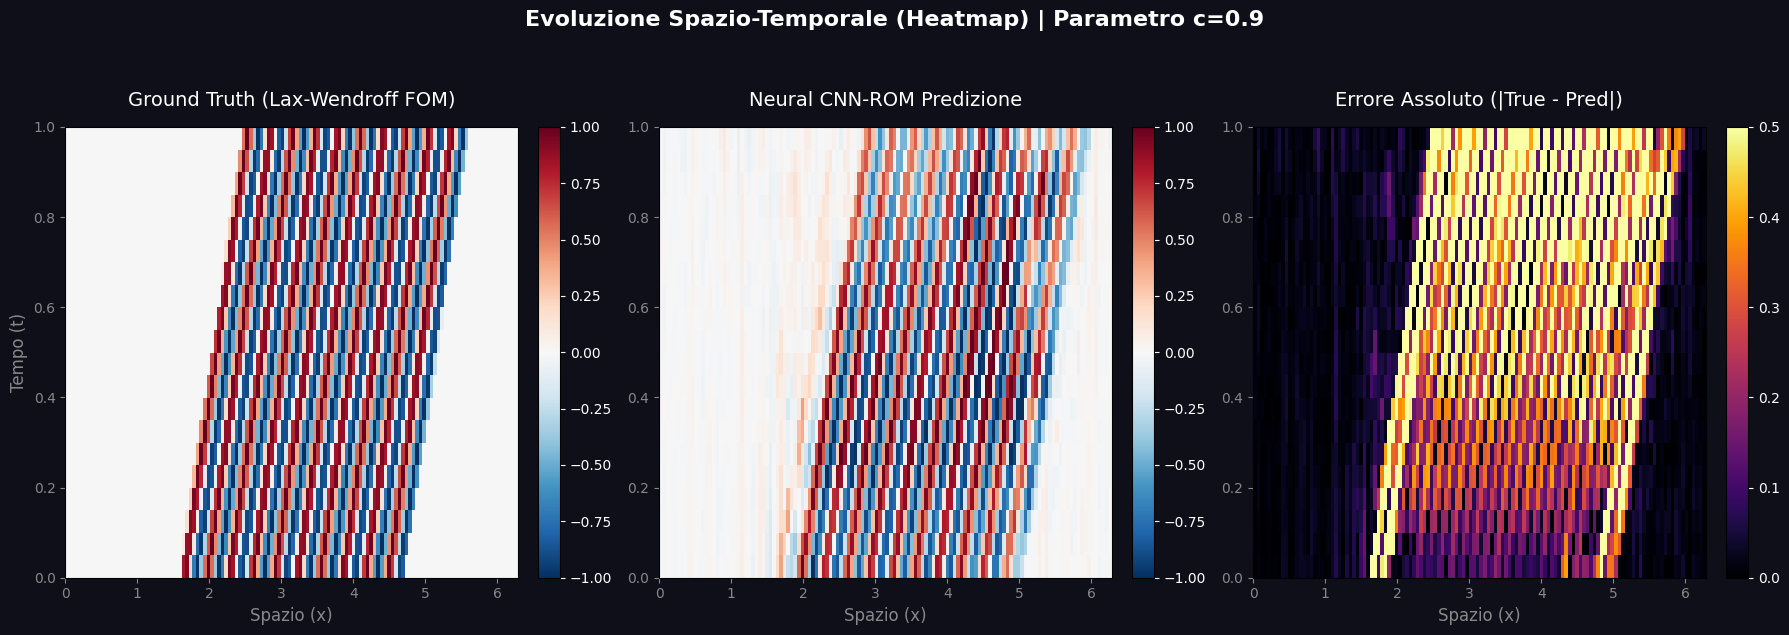

In [ ]:
# Scegliamo sempre il parametro di test c=0.9
c_demo = c_test[1]

# Estraiamo le matrici intere (Spazio x Tempo)
mat_true = trajs_test[c_demo]          # Ground Truth (Nx, Nt)
mat_pred = neural_preds[c_demo]        # Neural CNN-ROM (Nx, Nt)

# Calcoliamo l'errore assoluto tra le due matrici
mat_err = np.abs(mat_true - mat_pred)

# Impostiamo i limiti per l'asse temporale e spaziale
extent = [0, L, 0, mat_true.shape[1] * dt * SNAP_STRIDE] # [x_min, x_max, t_min, t_max]

# Creiamo la figura con 3 subplot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0f0f1a')
cmap = 'RdBu_r'
vmax = np.max(np.abs(mat_true))

titoli = ["Ground Truth (Lax-Wendroff FOM)",
          "Neural CNN-ROM Predizione",
          "Errore Assoluto (|True - Pred|)"]
matrici = [mat_true, mat_pred, mat_err]

for i, ax in enumerate(axes):
    ax.set_facecolor('#16213e')

    if i == 2:
        im = ax.imshow(matrici[i].T, origin='lower', aspect='auto',
                       extent=extent, cmap='inferno', vmin=0, vmax=vmax*0.5)
    else:
        im = ax.imshow(matrici[i].T, origin='lower', aspect='auto',
                       extent=extent, cmap=cmap, vmin=-vmax, vmax=vmax)

    ax.set_title(titoli[i], color='white', pad=15, fontsize=14)
    ax.set_xlabel("Spazio (x)", color='#888', fontsize=12)
    if i == 0:
        ax.set_ylabel("Tempo (t)", color='#888', fontsize=12)

    ax.tick_params(colors='#888')

    # Barra dei colori
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.yaxis.set_tick_params(color='white', labelcolor='white')

plt.suptitle(f"Evoluzione Spazio-Temporale (Heatmap) | Parametro c={c_demo}",
             color='white', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

La visualizzazione spazio-temporale conferma quantitativamente
le conclusioni spettrali. La rete cattura perfettamente la
propagazione diagonale dell'onda a velocità $c=0.9$, replicando
la struttura portante del segnale su tutto l'orizzonte temporale.
L'errore assoluto si concentra esclusivamente sui fronti d'onda,
ovvero nelle regioni a gradiente spaziale elevato: questo è
esattamente il comportamento atteso dallo *spectral bias*, che
porta la rete a filtrare le discontinuità ad alta frequenza
piuttosto che fittarle in modo instabile.

# FURTHER IMPROVEMENT
A partire da questo lavoro potrebbero risultare validare ulteriori esperimenti che al momento lasciano indubbiamente domande aperte riguardo il progetto come:

1) Provare a vedere se considerando una PDE con condizioni al bordo non periodiche la rete potrebbe funzionare lo stesso. Se si vuole vuole testare questo esperimento è raccomandabile togliere dagli strati convoluzionali in mode *circular* per il padding.
2) Testare il modello in circostanze di Sparsità strutturata come quella effettiva del Sensor displacement [2].
3) Un caso più interessante su cui testare l'architettura potrebbe essere delle PDE come quella di Burgers e osservare se anche in questo tipo di problemi l'approccio neurale cosi definito riesce a ottenere soluzioni plausibili

# APPENDICE


## A1. Decadimento dei valori singolari nell'equazione del trasporto

Sulla base dell'analisi teorica condotta da Arbes, Greif e Urban (2025) [3], consideriamo la $N$-width di Kolmogorov, definita come:

$$d_N(\mathcal{P}) := \inf_{\substack{V_N \subset L^2(\Omega) \\ \dim(V_N) = N}} \sup_{u \in \mathcal{P}} \inf_{v \in V_N} \|u - v\|_{L^2(\Omega)},$$

ossia l'errore minimo assoluto che sei costretto a commettere se cerchi di approssimare tutte le possibili soluzioni del tuo problema usando un **sottospazio lineare di dimensione n**.

Nel caso specifico di problemi governati da un dato iniziale discontinuo, come la nostra funzione indicatrice:

$$u_0(x) = \mathbf{1}_{[\pi/2,\,3\pi/2]}(x),$$

gli autori dimostrano che, per una condizione iniziale appartenente allo spazio di Sobolev $H^r$, i valori singolari della matrice degli snapshot decadono asintoticamente come $\sigma_N \sim N^{-(r+1/2)}$.

Questo tasso di decadimento è *sharp* (ottimale) e implica che la $N$-width è vincolata dalla relazione:

$$d_N(\mathcal{P}) \leq c_r N^{-(r+1/2)}.$$

Nel nostro caso specifico, si dimostra che le funzioni con una discontinuità di salto, come la nostra, appartengono ad $H^r$ con $r \leq \frac{1}{
2}$, da cui otteniamo che $\sigma_N$ decade asintoticamente come:
$$\sigma_N \sim N^{[\frac{1}{2}, 1)}$$

In sintesi, l'articolo quantifica rigorosamente il problema: in presenza di discontinuità, il decadimento è intrinsecamente lento e stabilisce una barriera matematica invalicabile, dimostrando che **nessun metodo di proiezione lineare può ottenere prestazioni migliori**.

## A2. Spiegazione intuitiva di come la rete aggira il problema del troncamento della base a $r$ valori.

Per poter in generale ridurre il problema originario immaginiamo di voler scrivere $(u(x))$ come combinazione lineare in una certa base, ossia:

$$
u(x,t) \approx \sum_{i=1}^r a_i(t)\,\phi_i(x)
$$

Consideriamo che la matrice su cui applichiamo la SVD ha la forma:

$$
X =
\begin{bmatrix}
u(x_1,t_1) & u(x_1,t_2) & \cdots & u(x_1,t_m) \\
u(x_2,t_1) & u(x_2,t_2) & \cdots & u(x_2,t_m) \\
\vdots & \vdots & \ddots & \vdots \\
u(x_n,t_1) & u(x_n,t_2) & \cdots & u(x_n,t_m)
\end{bmatrix}
=
\big[u(\cdot,t_1),\,u(\cdot,t_2),\,\dots,\,u(\cdot,t_m)\big]
$$

quindi, poiché noi cerchiamo il modo associato che massimizza l’energia proiettata:

$$
J(\phi)=\|X^T\phi\|^2
\quad \text{con } \|\phi\|=1,
$$

possiamo riscrivere:

$$
J(\phi)=\phi^T XX^T \phi.
$$

Nel caso in cui il rango di questa matrice sia basso allora:

$$
\operatorname{rank}(XX^T)=r \ll n,
$$

ciò implica che solo pochi autovalori sono significativi:

$$
\lambda_i = \frac{\sigma_i^2}{m}, \qquad i=1,\dots,r,
$$

e quindi la dinamica del sistema può essere ben approssimata tramite pochi modi:

$$
u(x,t) \approx \sum_{i=1}^r a_i(t)\,\phi_i(x),
$$

dove $\phi_i$ sono gli autovettori di $XX^T$ (equivalentemente le colonne di $U$ nella SVD $X=U\Sigma V^T$).

Viceversa, nel caso in cui il rango sia alto:

$$
\operatorname{rank}(XX^T) \approx n,
$$

gli autovalori decadono lentamente:
$$
\lambda_1 \ge \lambda_2 \ge \cdots \ge \lambda_n,
$$

e l’energia del sistema risulta distribuita su molti modi. In questo caso la rappresentazione POD richiede un numero elevato di funzioni base $\phi_i$, rendendo la riduzione di ordine inefficiente e poco compressiva.

Tuttavia, poiché consideriamo problemi di trasporto con condizioni al contorno periodiche (PBC), la soluzione può essere scritta come

$$
u(x,t) = u_0(x-ct).
$$

Osserviamo subito che la dinamica è una semplice traslazione nello spazio. In particolare, se moltiplichiamo entrambi i membri per una funzione esponenziale complessa $e^{ikx}$ e integriamo su un periodo, otteniamo che ciascuna armonica di Fourier evolve indipendentemente nel tempo.

Infatti, definendo i coefficienti di Fourier iniziali

$$
\hat{u}_k(0) = \int_0^{2\pi} u_0(x)\,e^{-ikx}\,dx,
$$

la soluzione in Fourier si scrive come

$$
u(x,t) = \sum_{k=-\infty}^{\infty} \hat{u}_k(0)\,e^{ik(x-ct)}
= \sum_{k=-\infty}^{\infty} \left(\hat{u}_k(0)e^{-ikct}\right)e^{ikx}.
$$

Osserviamo quindi che $e^{ikx}$ sono autofunzioni dell’operatore di traslazione periodico, nel senso che la traslazione agisce come

$$
\mathcal{T}_c u(x) = u(x-ct)
\quad \Rightarrow \quad
\mathcal{T}_c e^{ikx} = e^{-ikct} e^{ikx}.
$$

Questo implica che le funzioni $e^{ikx}$ sono autofunzioni (o modi propri) dell’operatore di trasporto con PBC e quindi formano una base naturale del problema.

Di conseguenza possiamo scrivere la soluzione anche nella forma generale

$$
u(x,t) \approx \sum_{i=1}^r a_i(t)\,\phi_i(x)
$$

con $\phi_i(x) = e^{ik_i x}$ nel caso di condizioni periodiche.

In questo modo abbiamo superato il problema della costruzione puramente empirica della base POD: invece di ottenere una base da un problema di correlazione spaziale $(XX^T)$, sfruttiamo direttamente la struttura dell’operatore dinamico, che è diagonalizzabile in Fourier.

In particolare, poiché ogni modo evolve indipendentemente come

$$
a_k(t) = \hat{u}_k(0)e^{-ikct},
$$

la dinamica non mescola i modi e non è necessario utilizzare una grande quantità di funzioni base per rappresentare la soluzione.

Infatti, l’energia del sistema rimane separata per ciascuna frequenza e la soluzione è completamente rappresentabile tramite pochi modi dominanti se lo spettro iniziale è concentrato:

$$
u(x,t) \approx \sum_{i=1}^r \hat{u}_{k_i}(0)\,e^{-ik_i ct} e^{ik_i x}.
$$

Questo mostra che, nel caso periodico, la base di Fourier non è solo una scelta conveniente ma coincide con la base di autofunzioni dell’operatore di trasporto, rendendo il problema già diagonalizzato e quindi evitando il mixing dei modi tipico della POD in coordinate spaziali fisse.

Tuttavia, nel caso in cui la soluzione dipendente da $u_0$ presenti forti discontinuità — come nel caso di un'onda quadra — il fenomeno di Gibbs implica che i coefficienti di Fourier decadono lentamente,

$$|\hat{u}_k(0)| \sim \frac{1}{|k|}, \qquad k \to \infty,$$

e quindi lo spettro non è concentrato su poche frequenze. Di conseguenza, per rappresentare fedelmente la soluzione occorre trattenere un numero $r$ molto elevato di modi, il che si riflette direttamente sul rango della matrice degli snapshot: $\operatorname{rank}(X) \approx \min(n,m)$, con autovalori di $XX^T$ che decadono lentamente. Sia la POD in coordinate spaziali fisse, sia la base di Fourier, risultano quindi basi lineari inadatte a comprimere efficientemente il problema in presenza di discontinuità.

Per superare questa limitazione consideriamo un Autoencoder (AE) con encoder e decoder realizzati tramite reti neurali convoluzionali (CNN), della forma

$$u(x,t) \approx \mathcal{D}_{\theta_\mathcal{D}}\!\left(\mathcal{E}_{\theta_\mathcal{E}}(u(\cdot,t))\right)(x),$$

i cui parametri $\theta = (\theta_\mathcal{E}, \theta_\mathcal{D})$ sono appresi minimizzando l'errore di ricostruzione sugli snapshot:

$$\min_{\theta_\mathcal{E},\,\theta_\mathcal{D}} \sum_{j=1}^m \left\|u(\cdot, t_j) - \mathcal{D}_{\theta_\mathcal{D}}\!\left(\mathcal{E}_{\theta_\mathcal{E}}(u(\cdot,t_j))\right)\right\|^2.$$

Sia $\mathbf{a}(t) = \mathcal{E}_{\theta_\mathcal{E}}(u(\cdot, t))$ la codifica latente estratta dalla matrice degli snapshot. Affinché l'architettura approssimi coerentemente la dinamica del sistema, proiettiamo lo stato sul piano tangente locale alla varietà non lineare generata dal decoder, calcolato in prossimità dello stato corrente $\mathbf{a}$.Sviluppando il decoder $\mathcal{D}_{\theta_\mathcal{D}}$ al primo ordine attorno a una generica configurazione latente $\mathbf{a}$, possiamo linearizzare localmente la mappa per piccole perturbazioni $\delta \mathbf{a}$:$$\mathcal{D}_{\theta_\mathcal{D}}(\mathbf{a} + \delta \mathbf{a}) \approx \mathcal{D}_{\theta_\mathcal{D}}(\mathbf{a}) + \sum_{i=1}^r \frac{\partial \mathcal{D}_{\theta_\mathcal{D}}(\mathbf{a})}{\partial a_i} \delta a_i$$Proiettando l'intero campo di stato sulla base di questo spazio tangente locale, la ricostruzione assume la struttura di una combinazione lineare dinamica:$$u(x,t) \approx \sum_{i=1}^r a_i(t) \, \phi_i(x; \mathbf{a})$$identificando i modi tangenti (che ora dipendono esplicitamente dal punto in cui ci troviamo sulla varietà) come:$$\phi_i(x; \mathbf{a}) := \frac{\partial \mathcal{D}_{\theta_\mathcal{D}}(\mathbf{a})(x)}{\partial a_i}$$.
L'utilizzo di AE infatti ci permette rispetto a lavori come **[3]**,**[4]**, di definire una base locale e non globale, dove quindi il problema riesce effettivamente a essere descritto con $k$ modi.

In analogia a quanto fatto in precedenza — dove i coefficienti $a_i(t)$ erano ottenuti tramite proiezione su una base fissa (integrale di Fourier) o tramite proiezione ottimale sui modi energetici (POD) — ora i coefficienti sono determinati direttamente dall'architettura dell'encoder:

$$\mathbf{a}(t) = \mathcal{E}_{\theta_\mathcal{E}}(u(\cdot,t)) \in \mathbb{R}^r.$$

Poiché $\mathcal{E}$ è una CNN con $L$ strati convoluzionali, filtri $\tilde{\Lambda}_l$ diagonalizzati dalla DFT e attivazioni non lineari $\sigma$, la sua azione esplicita è:

$$\mathbf{a}(t) = G_r\,\sigma\!\left(F^{-1}\tilde{\Lambda}_L\,\sigma\!\left(\cdots\sigma\!\left(F^{-1}\tilde{\Lambda}_1\, F\, u(\cdot,t)\right)\cdots\right)\right),$$

dove $F$ è la matrice DFT, $G_r \in \mathbb{R}^{r \times n}$ è la proiezione finale sullo spazio latente, e ogni strato applica prima un filtraggio in frequenza ($\tilde{\Lambda}_l$) e poi una non linearità puntuale ($\sigma$). I coefficienti $a_i(t)$ sono dunque una rappresentazione compressa, non lineare e adattiva di $u(\cdot,t)$, ben diversa dalla proiezione lineare di Fourier o POD.

Il decoder $\mathcal{D}$ ha struttura speculare all'encoder: le operazioni sono le inverse di quelle dell'encoder, con filtri $\Lambda_l = \tilde{\Lambda}_l^{-1}$ e trasformazioni $F^{-1}$ al posto di $F$. Differenziando rispetto ad $a_i$ tramite la regola della catena attraverso tutti gli strati, e denotando con

$$\mathbf{z}^{(l)} = \sigma\!\left(F^{-1}\tilde{\Lambda}_l\,\mathbf{z}^{(l-1)}\right), \quad \mathbf{z}^{(0)} = F\,u(\cdot,t), \qquad \mathbf{J}^{(l)} = \mathrm{diag}\!\left(\sigma'\!\left(\mathbf{z}^{(l)}\right)\right)$$

le attivazioni intermedie e i relativi Jacobiani dell'encoder, si ottiene:

$$\phi_i(x;\mathbf{a}) = \left[F^{-1}\tilde{\Lambda}_L^{-1}\,\mathbf{J}^{(L-1)}(\mathcal{E}(u))\cdots \mathbf{J}^{(1)}(\mathcal{E}(u))\,\tilde{\Lambda}_1^{-1}\,F\right]_{x,i}.$$

La rappresentazione completa della soluzione diventa quindi:

$$u(x,t) \approx \sum_{i=1}^r \underbrace{\Bigl[G_r\,\sigma\!\left(F^{-1}\tilde{\Lambda}_L\,\sigma\!\left(\cdots\sigma\!\left(F^{-1}\tilde{\Lambda}_1\,F\,u\right)\cdots\right)\right)\Bigr]_i}_{a_i(t)}\;\cdot\; \underbrace{\Bigl[F^{-1}\tilde{\Lambda}_L^{-1}\,\mathbf{J}^{(L-1)}(\mathcal{E}(u))\cdots\mathbf{J}^{(1)}(\mathcal{E}(u))\,\tilde{\Lambda}_1^{-1}\,F\Bigr]_{x,i}}_{\phi_i(x;\,\mathbf{a})}.$$

Osserviamo che i $\phi_i(x;\mathbf{a})$ non sono funzioni fisse: le matrici $\mathbf{J}^{(l)}(\mathcal{E}(u))$ dipendono dalle attivazioni intermedie dell'encoder, che dipendono a loro volta da $u(\cdot,t)$. La base si adatta alla soluzione corrente — se $u$ presenta una discontinuità in una certa posizione, i filtri convoluzionali la localizzano e i Jacobiani si concentrano in quella regione. Questo è strutturalmente impossibile con POD o Fourier, dove i $\phi_i$ sono fissati una volta per tutte:

* Fourier: $\phi_i(x) = e^{ik_i x}$, base fissa, $a_i(t) = \hat{u}_{k_i}(0)e^{-ik_i ct}$ calcolato per integrazione esplicita;
* POD: $\phi_i(x) = [U]_{x,i}$ autovettori di $XX^T$, fissi dopo la decomposizione offline, $a_i(t) = \phi_i^T u(\cdot,t)$ proiezione lineare;
* CNN-AE: $\phi_i(x;\mathbf{a})$ adattativi, $a_i(t) = [\mathcal{E}(u(\cdot,t))]_i$ proiezione non lineare locale appresa.

Con POD o Fourier, la troncatura a $r$ termini è forzata e introduce un errore sistematico: i modi scartati perdono energia reale perché la base non può adattarsi. Con CNN-AE invece, $r$ termini non lineari adattativi coprono uno spazio funzionale molto più ricco di $r$ termini lineari fissi:

$$\operatorname{span}_{\mathbf{a}}\{\phi_i(\cdot;\mathbf{a})\}_{i=1}^r \supset \operatorname{span}\{\phi_i(\cdot)\}_{i=1}^r \quad \text{(POD o Fourier)}.$$
Inoltre, l’ordine con cui i coefficienti latenti vengono appresi non è arbitrario, ma è indotto dalla dinamica dell’ottimizzazione. Consideriamo un aggiornamento di tipo gradient descent (o SGD in regime batch sufficientemente grande) sui parametri $\theta$:

$$
\theta^{(k+1)} = \theta^{(k)} - \eta \nabla_\theta \mathcal{L}(\theta^{(k)}).
$$

Linearizzando il modello nel regime NTK attorno a $\theta_0$, la dinamica dell’output può essere scritta come:

$$
\frac{d e}{d\tau} = -K_{\mathrm{NTK}} e,
$$

dove $e = f_\theta - u$ e il kernel è dato da

$$
K_{\mathrm{NTK}}(t_i,t_j)
=
\nabla_\theta f(t_i)\cdot \nabla_\theta f(t_j).
$$

Diagonalizzando l’operatore kernel si ottiene una base di autofunzioni $\{\psi_s\}$ con autovalori $\mu_s$:

$$
K \psi_s = \mu_s \psi_s.
$$

Espandendo l’errore in tale base, le componenti evolvono indipendentemente secondo:

$$
e_s(\tau) = e^{-\mu_s \tau} e_s(0).
$$

In particolare, per architetture convoluzionali il kernel è approssimativamente traslazione-invariante, e le sue autofunzioni sono ben approssimate dalle armoniche di Fourier. In questo caso gli autovalori $\mu_s$ decrescono con la frequenza spaziale $|k|$, inducendo una dinamica di apprendimento spettrale.

Di conseguenza, le componenti a bassa frequenza dell’errore (associate ai modi più regolari e energeticamente dominanti) vengono attenuate più rapidamente rispetto alle componenti ad alta frequenza. Questo implica che, durante il training, i coefficienti latenti associati a tali direzioni vengono appresi prima e con maggiore accuratezza, realizzando un ordinamento implicito dei modi:

$$
\mu_1 \ge \mu_2 \ge \cdots \ge \mu_r,
\qquad
e_i(\tau)=e^{-\mu_i \tau} e_i(0).
$$

In questo senso, non solo la rappresentazione induce una base locale adattiva (tramite il Jacobiano del decoder), ma la dinamica di ottimizzazione seleziona progressivamente le direzioni latenti più rilevanti, realizzando una forma di troncamento “emergente” anziché imposta a priori.

**References**:

**[3]**. "Non intrusive reduced order modeling of parametrized PDEs by kernel POD and neural networks", Salvator et al. (2021) (https://arxiv.org/abs/2103.17152)

**[4]**. "Non-intrusive reduced order modeling of nonlinear problems using neural networks", Heastaven et al. (2018), (https://www.sciencedirect.com/science/article/pii/S0021999118301190)